# How Performative Is My Music Taste?
### Analyzing 152,000+ Last.fm Scrobbles to Measure Authenticity vs. Curation

---

**Author:** Mahir Abdullah  
**Date:** March 2026  
**Tools:** Python, Pandas, Seaborn, Matplotlib  
**Data Source:** Personal Last.fm scrobble history (Aug 2021 – Mar 2026)

---

## Introduction

In online music communities, the term **"performative listening"** describes the tendency to curate one's music taste for social validation rather than genuine enjoyment. Performative listeners might:

- Disproportionately listen to critically acclaimed "canon" artists to build credibility
- Binge trending artists briefly without deep engagement
- Avoid mainstream/pop artists to maintain an "underground" image
- Listen to artists primarily because they're associated with a specific online aesthetic

**Research Question:** Using 152,000+ scrobbles over 4.5 years, can we quantify how "performative" a listener's habits are by measuring overlap with critical consensus, mainstream popularity, listening depth, and engagement patterns?

This project builds a multi-factor **Performativity Score** and analyzes listening behavior across several dimensions to answer this question.

## 1. Setup & Data Loading

In [97]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Style settings
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

# Custom color palette
COLORS = ['#1DB954', '#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#FF8C42']

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [98]:
# Load the Last.fm scrobble data
# NOTE: If using Google Colab, upload the file first:
#   from google.colab import files
#   uploaded = files.upload()

df = pd.read_csv('/Users/mahirabdullah/Documents/Projects/performativityProject/Last_fm_Data.csv', header=None, 
                 names=['artist', 'album', 'track', 'timestamp'])

print(f'Total scrobbles loaded: {len(df):,}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Total scrobbles loaded: 152,567
Columns: ['artist', 'album', 'track', 'timestamp']


,artist,album,track,timestamp
0,Kendrick Lamar,good kid m.A.A.d city,Bitch Don’t Kill My Vibe - Remix,NaN
1,Joey Bada$$,ALL-AMERIKKKAN BADA$$,Devastated,17 Mar 2026 02:19
2,FKA twigs,MAGDALENE,fallen alien,16 Mar 2026 21:51
3,Magdalena Bay,Imaginal Disk,Tunnel Vision,16 Mar 2026 21:46
4,Khalid,American Teen,Location,16 Mar 2026 21:42
5,twenty one pilots,Drag Path,Drag Path,16 Mar 2026 21:42
6,twenty one pilots,Drag Path,Drag Path,16 Mar 2026 21:39
7,The Marías,No One Noticed (Extended),No One Noticed (Extended Spanish),16 Mar 2026 21:39
8,Mac Miller,Swimming,What's the Use?,16 Mar 2026 21:20
9,Logic,Vinyl Days,Breath Control (feat. Wiz Khalifa),16 Mar 2026 21:18


## 2. Data Cleaning & Preparation

In [99]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal rows: {len(df):,}')

Missing values per column:
artist          0
album        4014
track           0
timestamp     756
dtype: int64

Total rows: 152,567


In [100]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', dayfirst=True)

# Drop rows with missing timestamps (can't analyze timing without them)
df = df.dropna(subset=['timestamp'])

# Fill missing album names
df['album'] = df['album'].fillna('Unknown Album')

# Extract time features
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['year_month'] = df['timestamp'].dt.to_period('M')
df['day_of_week'] = df['timestamp'].dt.day_name()
df['hour'] = df['timestamp'].dt.hour
df['date'] = df['timestamp'].dt.date

print(f'Clean dataset: {len(df):,} scrobbles')
print(f'Date range: {df.timestamp.min().strftime("%B %d, %Y")} to {df.timestamp.max().strftime("%B %d, %Y")}')
print(f'Unique artists: {df.artist.nunique():,}')
print(f'Unique tracks: {df.track.nunique():,}')
print(f'Unique albums: {df.album.nunique():,}')

Clean dataset: 151,811 scrobbles
Date range: August 16, 2021 to March 17, 2026
Unique artists: 3,023
Unique tracks: 13,632
Unique albums: 4,323


## 3. Exploratory Data Analysis: Who Do I Actually Listen To?

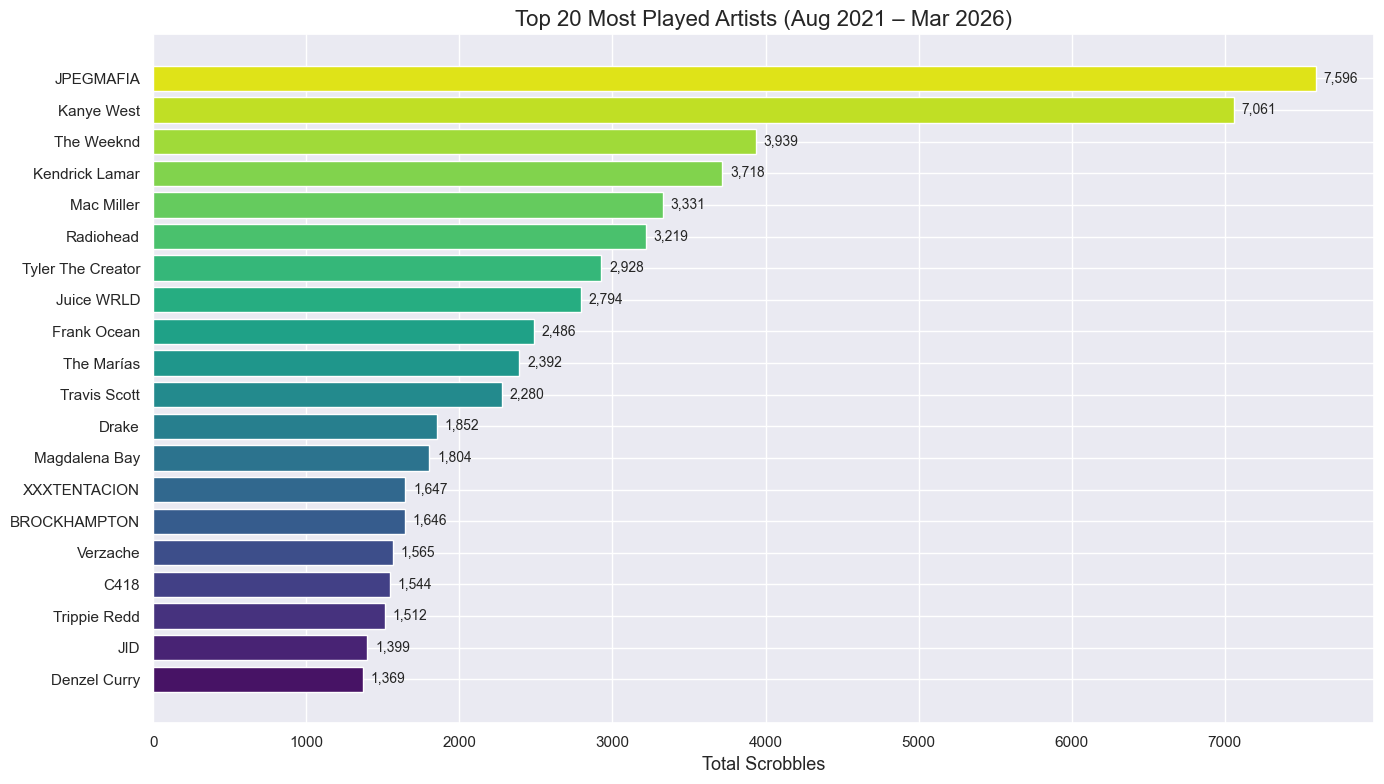


Top 5 artists account for 25,645 scrobbles (16.9% of all listening)


In [101]:
# Top 20 most-played artists
top20_artists = df['artist'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(top20_artists.index[::-1], top20_artists.values[::-1], 
               color=sns.color_palette('viridis', 20))
ax.set_xlabel('Total Scrobbles')
ax.set_title('Top 20 Most Played Artists (Aug 2021 – Mar 2026)')

# Add value labels
for bar, val in zip(bars, top20_artists.values[::-1]):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,}', 
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f'\nTop 5 artists account for {top20_artists.head(5).sum():,} scrobbles '
      f'({top20_artists.head(5).sum()/len(df)*100:.1f}% of all listening)')

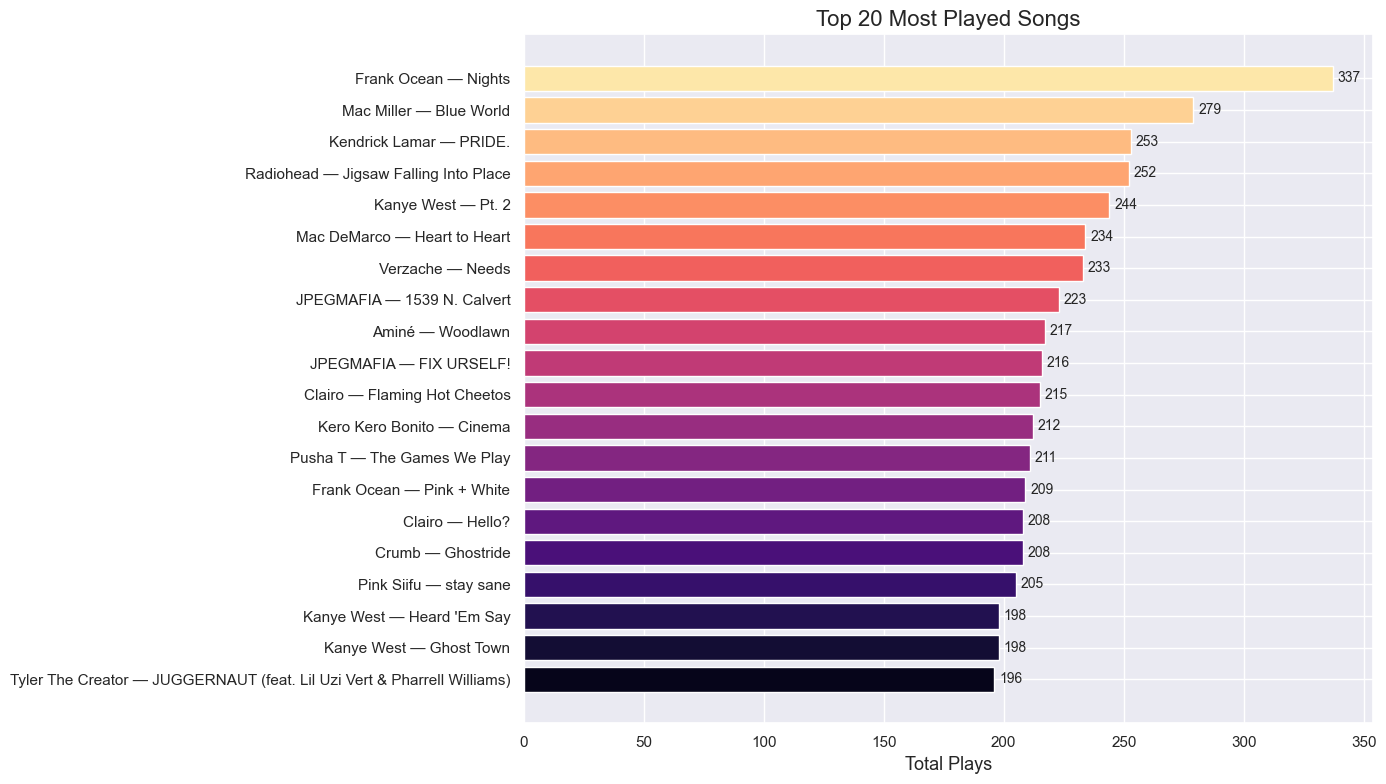

In [102]:
# Top 20 most-played tracks
top_tracks = df.groupby(['artist', 'track']).size().reset_index(name='plays')
top_tracks = top_tracks.sort_values('plays', ascending=False).head(20)
top_tracks['label'] = top_tracks['artist'] + ' — ' + top_tracks['track']

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(top_tracks['label'].values[::-1], top_tracks['plays'].values[::-1],
               color=sns.color_palette('magma', 20))
ax.set_xlabel('Total Plays')
ax.set_title('Top 20 Most Played Songs')

for bar, val in zip(bars, top_tracks['plays'].values[::-1]):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2, str(val), 
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 4. Performativity Analysis

Now we get to the core question. We'll measure "performativity" through **5 different lenses**, each capturing a different aspect of whether listening is authentic or curated:

| Factor | What It Measures | Performative Signal |
|--------|-----------------|--------------------|
| **Critical Canon Overlap** | How much listening aligns with "essential" album lists | High overlap = possibly curated for credibility |
| **Mainstream Concentration** | How top-heavy the listening is | All top artists = safe/performative choices |
| **Listening Depth** | Album vs. single-track engagement | Only hits = surface-level / performative |
| **Trend Chasing** | Binge-then-drop patterns | Fast spikes = chasing trends |
| **Discovery vs. Repetition** | New artist exploration over time | Stale library = aesthetic locked in |
| **Girl-Appeal Index** | Concentration of "green flag" artists | High % = curating taste for romantic appeal |
| **Drain/Internet-Core** | Concentration of online-identity artists | High % = terminally online aesthetic curation |
| **Tough Guy Rap** | Concentration of aggressive/hard rap | High % = performing masculinity through music |


### 4.1 Critical Canon Overlap Score

If someone's top artists are *exclusively* the most critically acclaimed artists of the generation (the ones every music Twitter account praises), that's a signal of performative taste. We compare the listening library against commonly cited "canon" artists across hip-hop, indie, electronic, and pop.

In [103]:
# Define "critical canon" artists — artists that are universally praised online
# and frequently appear on "essential listening" lists.
# This list is intentionally broad across genres.

critical_canon = {
    # Hip-hop/Rap canon
    'Kendrick Lamar', 'Kanye West', 'Frank Ocean', 'Tyler The Creator',
    'MF DOOM', 'J. Cole', 'JAY-Z', 'Nas', 'OutKast', 'A Tribe Called Quest',
    'Pusha T', 'Freddie Gibbs', 'Danny Brown', 'Earl Sweatshirt',
    'Vince Staples', 'JID', 'Denzel Curry', 'Childish Gambino',
    'Joey Bada$$', 'Mac Miller', 'Saba',
    
    # Indie/Alternative canon
    'Radiohead', 'Tame Impala', 'Arctic Monkeys', 'The Strokes',
    'Bon Iver', 'Fleet Foxes', 'Beach House', 'Arcade Fire',
    'Sufjan Stevens', 'Phoebe Bridgers', 'Mitski',
    
    # R&B/Pop canon
    'The Weeknd', 'SZA', 'Solange', 'FKA twigs', 'Charli xcx',
    'Billie Eilish', 'Lorde', 'Rina Sawayama',
    
    # Electronic canon
    'Aphex Twin', 'Boards of Canada', 'Flying Lotus', 'Burial',
    'Daft Punk', 'Flume', 'SOPHIE',
    
    # Experimental/other canon
    'JPEGMAFIA', 'Death Grips', 'Injury Reserve', 'Björk',
    'King Krule', 'Black Midi', 'Gorillaz'
}

print(f'Canon list size: {len(critical_canon)} artists')

# Calculate what % of total listening is canon artists
df['is_canon'] = df['artist'].isin(critical_canon)
canon_pct = df['is_canon'].mean() * 100

# What % of your top 50 artists are canon?
top50 = df['artist'].value_counts().head(50).index
top50_canon = sum(1 for a in top50 if a in critical_canon)
top50_canon_pct = top50_canon / 50 * 100

print(f'\n--- Critical Canon Overlap ---')
print(f'Scrobbles on canon artists: {df.is_canon.sum():,} / {len(df):,} ({canon_pct:.1f}%)')
print(f'Canon artists in your top 50: {top50_canon} / 50 ({top50_canon_pct:.0f}%)')

if canon_pct > 60:
    print('\n⚠️  HIGH canon overlap — your library reads like a RateYourMusic starter pack.')
elif canon_pct > 35:
    print('\n📊 MODERATE canon overlap — solid taste with room for personality.')
else:
    print('\n✅ LOW canon overlap — your taste goes well beyond the usual suspects.')

Canon list size: 54 artists

--- Critical Canon Overlap ---
Scrobbles on canon artists: 53,872 / 151,811 (35.5%)
Canon artists in your top 50: 23 / 50 (46%)

📊 MODERATE canon overlap — solid taste with room for personality.


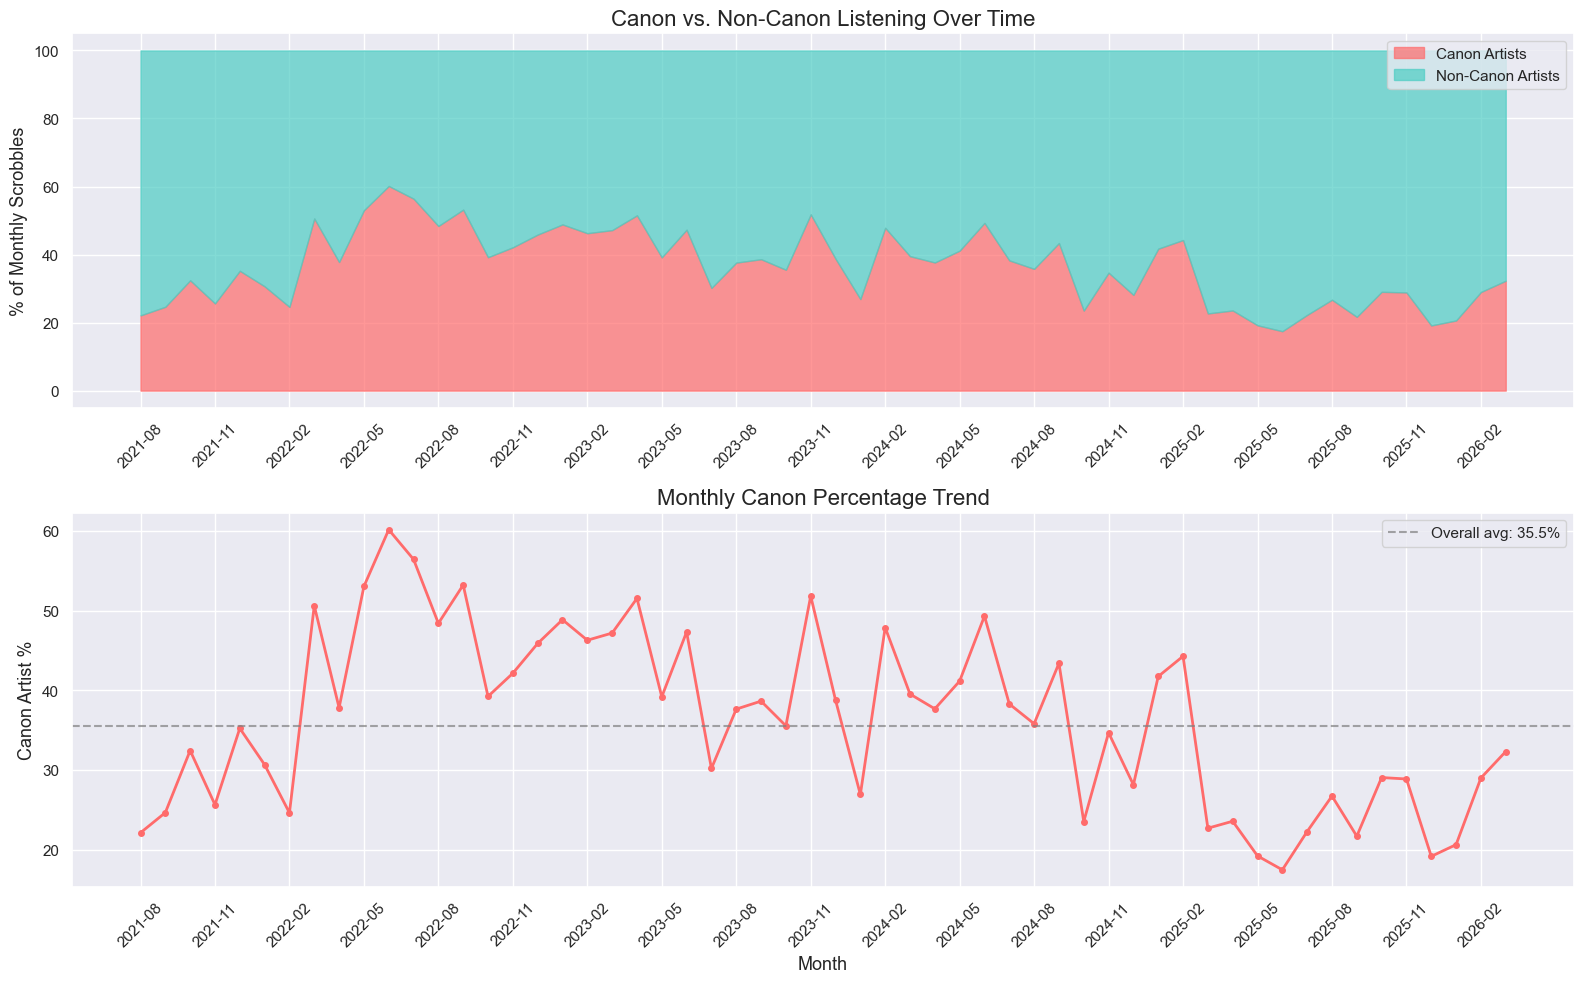

In [104]:
# Visualize: Canon vs. Non-Canon listening over time
canon_by_month = df.groupby(['year_month', 'is_canon']).size().unstack(fill_value=0)
canon_by_month.columns = ['Non-Canon', 'Canon']
canon_by_month_pct = canon_by_month.div(canon_by_month.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Stacked area chart
x = range(len(canon_by_month_pct))
ax1.fill_between(x, 0, canon_by_month_pct['Canon'], alpha=0.7, color='#FF6B6B', label='Canon Artists')
ax1.fill_between(x, canon_by_month_pct['Canon'], 100, alpha=0.7, color='#4ECDC4', label='Non-Canon Artists')
ax1.set_ylabel('% of Monthly Scrobbles')
ax1.set_title('Canon vs. Non-Canon Listening Over Time')
ax1.legend(loc='upper right')
ax1.set_xticks(x[::3])
ax1.set_xticklabels([str(p) for p in canon_by_month_pct.index[::3]], rotation=45)

# Monthly canon percentage line
ax2.plot(x, canon_by_month_pct['Canon'], color='#FF6B6B', linewidth=2, marker='o', markersize=4)
ax2.axhline(y=canon_pct, color='gray', linestyle='--', alpha=0.7, label=f'Overall avg: {canon_pct:.1f}%')
ax2.set_ylabel('Canon Artist %')
ax2.set_xlabel('Month')
ax2.set_title('Monthly Canon Percentage Trend')
ax2.legend()
ax2.set_xticks(x[::3])
ax2.set_xticklabels([str(p) for p in canon_by_month_pct.index[::3]], rotation=45)

plt.tight_layout()
plt.show()

### 4.2 Listening Depth Score

A performative listener tends to only play the **hits** — they know the singles but haven't explored deep cuts. An authentic listener explores full albums and lesser-known tracks. We measure this by looking at how many unique tracks you play per artist relative to how much you listen to them.

In [105]:
# For each artist: total scrobbles vs unique tracks played
artist_depth = df.groupby('artist').agg(
    total_plays=('track', 'size'),
    unique_tracks=('track', 'nunique'),
    unique_albums=('album', 'nunique')
).reset_index()

# Depth ratio: unique tracks / total plays
# Low ratio = playing same few songs on repeat (surface level)
# High ratio = exploring many different tracks (deep engagement)
artist_depth['depth_ratio'] = artist_depth['unique_tracks'] / artist_depth['total_plays']
artist_depth['avg_plays_per_track'] = artist_depth['total_plays'] / artist_depth['unique_tracks']

# Focus on artists with at least 100 plays (meaningful sample)
deep = artist_depth[artist_depth['total_plays'] >= 100].sort_values('depth_ratio')

print('=== SHALLOWEST LISTENING (fewest unique tracks relative to plays) ===')
print('These artists you mostly replay the same songs:\n')
shallow = deep.head(15)[['artist', 'total_plays', 'unique_tracks', 'avg_plays_per_track']]
shallow.columns = ['Artist', 'Total Plays', 'Unique Tracks', 'Avg Plays/Track']
print(shallow.to_string(index=False))

print('\n\n=== DEEPEST LISTENING (most unique tracks relative to plays) ===')
print('These artists you explore widely:\n')
deepest = deep.tail(15)[['artist', 'total_plays', 'unique_tracks', 'avg_plays_per_track']]
deepest.columns = ['Artist', 'Total Plays', 'Unique Tracks', 'Avg Plays/Track']
print(deepest.to_string(index=False))

=== SHALLOWEST LISTENING (fewest unique tracks relative to plays) ===
These artists you mostly replay the same songs:

          Artist  Total Plays  Unique Tracks  Avg Plays/Track
 KIDS SEE GHOSTS          614              8        76.750000
            SOFY          146              2        73.000000
          Clipse          679             13        52.230769
       Mura Masa          101              2        50.500000
           Stuts          148              3        49.333333
      The Marías         2392             52        46.000000
       JPEGMAFIA         7596            188        40.404255
       Radiohead         3219             94        34.244681
     Frank Ocean         2486             75        33.146667
   Geordie Greep          364             11        33.090909
Kero Kero Bonito         1367             43        31.790698
       Baby Keem         1137             36        31.583333
  Arctic Monkeys          182              6        30.333333
        Verza

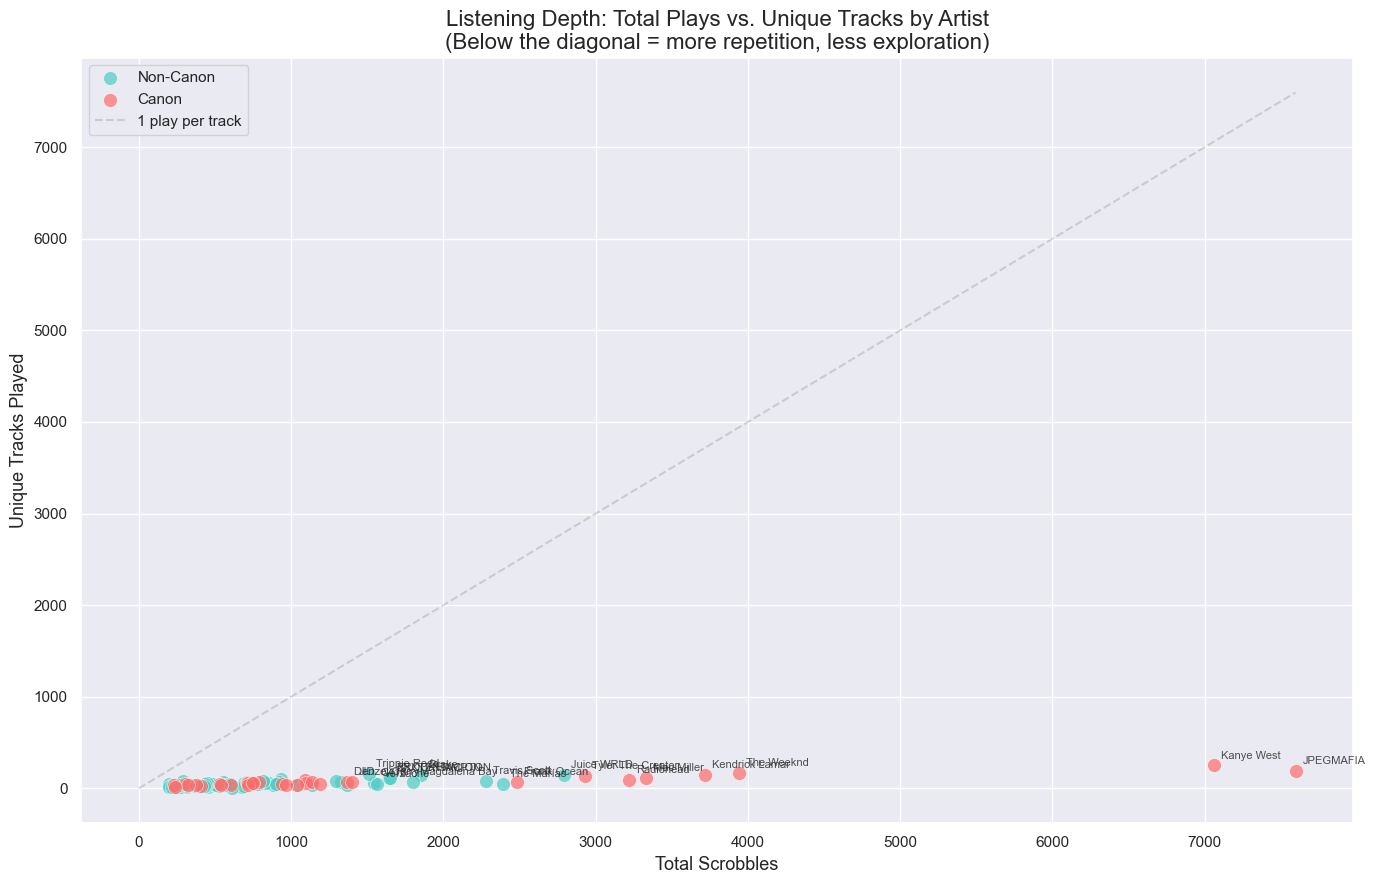


Overall Listening Depth Score: 0.093
(Closer to 1.0 = exploring many tracks per artist, closer to 0 = replaying same songs)


In [106]:
# Scatter plot: plays vs unique tracks for top artists
top_artists_depth = artist_depth[artist_depth['total_plays'] >= 200].copy()
top_artists_depth['is_canon'] = top_artists_depth['artist'].isin(critical_canon)

fig, ax = plt.subplots(figsize=(14, 9))

# Plot non-canon
non_canon = top_artists_depth[~top_artists_depth['is_canon']]
canon = top_artists_depth[top_artists_depth['is_canon']]

ax.scatter(non_canon['total_plays'], non_canon['unique_tracks'], 
           s=100, alpha=0.7, color='#4ECDC4', label='Non-Canon', edgecolors='white', linewidth=0.5)
ax.scatter(canon['total_plays'], canon['unique_tracks'],
           s=100, alpha=0.7, color='#FF6B6B', label='Canon', edgecolors='white', linewidth=0.5)

# Label key artists
for _, row in top_artists_depth.nlargest(20, 'total_plays').iterrows():
    ax.annotate(row['artist'], (row['total_plays'], row['unique_tracks']),
                fontsize=8, alpha=0.8, 
                xytext=(5, 5), textcoords='offset points')

# Add diagonal reference line (1 play per track)
max_val = top_artists_depth['total_plays'].max()
ax.plot([0, max_val], [0, max_val], '--', color='gray', alpha=0.3, label='1 play per track')

ax.set_xlabel('Total Scrobbles')
ax.set_ylabel('Unique Tracks Played')
ax.set_title('Listening Depth: Total Plays vs. Unique Tracks by Artist\n(Below the diagonal = more repetition, less exploration)')
ax.legend()
plt.tight_layout()
plt.show()

# Overall depth score
overall_depth = deep['depth_ratio'].mean()
print(f'\nOverall Listening Depth Score: {overall_depth:.3f}')
print(f'(Closer to 1.0 = exploring many tracks per artist, closer to 0 = replaying same songs)')

### 4.3 Trend Chasing Index

Performative listeners often **binge** a new artist when they're trending, then drop them entirely. Authentic listeners maintain more consistent relationships with artists over time. We measure this by looking at how "spikey" vs. "sustained" listening is for each artist.

In [107]:
# For each artist, calculate their listening timeline
def calculate_trend_score(artist_df):
    """Calculate how 'binge-y' listening to an artist is.
    High score = concentrated in short bursts (trend chasing)
    Low score = spread evenly over time (sustained interest)"""
    
    monthly = artist_df.groupby(artist_df['timestamp'].dt.to_period('M')).size()
    if len(monthly) < 2:
        return np.nan
    
    # Coefficient of variation: std / mean
    # Higher = more concentrated/spikey listening
    cv = monthly.std() / monthly.mean() if monthly.mean() > 0 else 0
    
    # What % of total plays happened in the peak month?
    peak_concentration = monthly.max() / monthly.sum()
    
    # How many months they appeared in vs total possible months
    total_months = len(df['year_month'].unique())
    presence = len(monthly) / total_months
    
    return peak_concentration

# Apply to artists with 100+ plays
top_artist_names = artist_depth[artist_depth['total_plays'] >= 100]['artist'].values
trend_scores = {}

for artist in top_artist_names:
    artist_data = df[df['artist'] == artist]
    trend_scores[artist] = calculate_trend_score(artist_data)

trend_df = pd.DataFrame({
    'artist': list(trend_scores.keys()),
    'peak_concentration': list(trend_scores.values())
}).dropna()

trend_df = trend_df.merge(artist_depth[['artist', 'total_plays']], on='artist')
trend_df['is_canon'] = trend_df['artist'].isin(critical_canon)

# Most binge-y (trend-chased) artists
print('=== MOST BINGE-LISTENED ARTISTS (Trend Chasing) ===')
print('High peak concentration = most plays crammed into one month\n')
bingy = trend_df.nlargest(15, 'peak_concentration')[['artist', 'total_plays', 'peak_concentration']]
bingy.columns = ['Artist', 'Total Plays', 'Peak Month % of Total']
bingy['Peak Month % of Total'] = (bingy['Peak Month % of Total'] * 100).round(1)
print(bingy.to_string(index=False))

print('\n\n=== MOST SUSTAINED ARTISTS (Genuine Long-Term Interest) ===')
print('Low peak concentration = listening spread evenly over time\n')
sustained = trend_df.nsmallest(15, 'peak_concentration')[['artist', 'total_plays', 'peak_concentration']]
sustained.columns = ['Artist', 'Total Plays', 'Peak Month % of Total']
sustained['Peak Month % of Total'] = (sustained['Peak Month % of Total'] * 100).round(1)
print(sustained.to_string(index=False))

=== MOST BINGE-LISTENED ARTISTS (Trend Chasing) ===
High peak concentration = most plays crammed into one month

                Artist  Total Plays  Peak Month % of Total
               Whoarei          216                   96.8
           St. Vincent          135                   83.0
           Ninajirachi          199                   82.9
         Armand Hammer          197                   81.2
          Tierra Whack          108                   80.6
       Porter Robinson          265                   77.7
                 SALES          173                   69.9
          Hippo Campus          161                   69.6
Black Country New Road          128                   69.5
               Amaarae          416                   65.6
         Janelle Monáe          270                   63.0
              Lil Peep          101                   61.4
            black midi          243                   58.8
               2hollis          120                   58.3
  

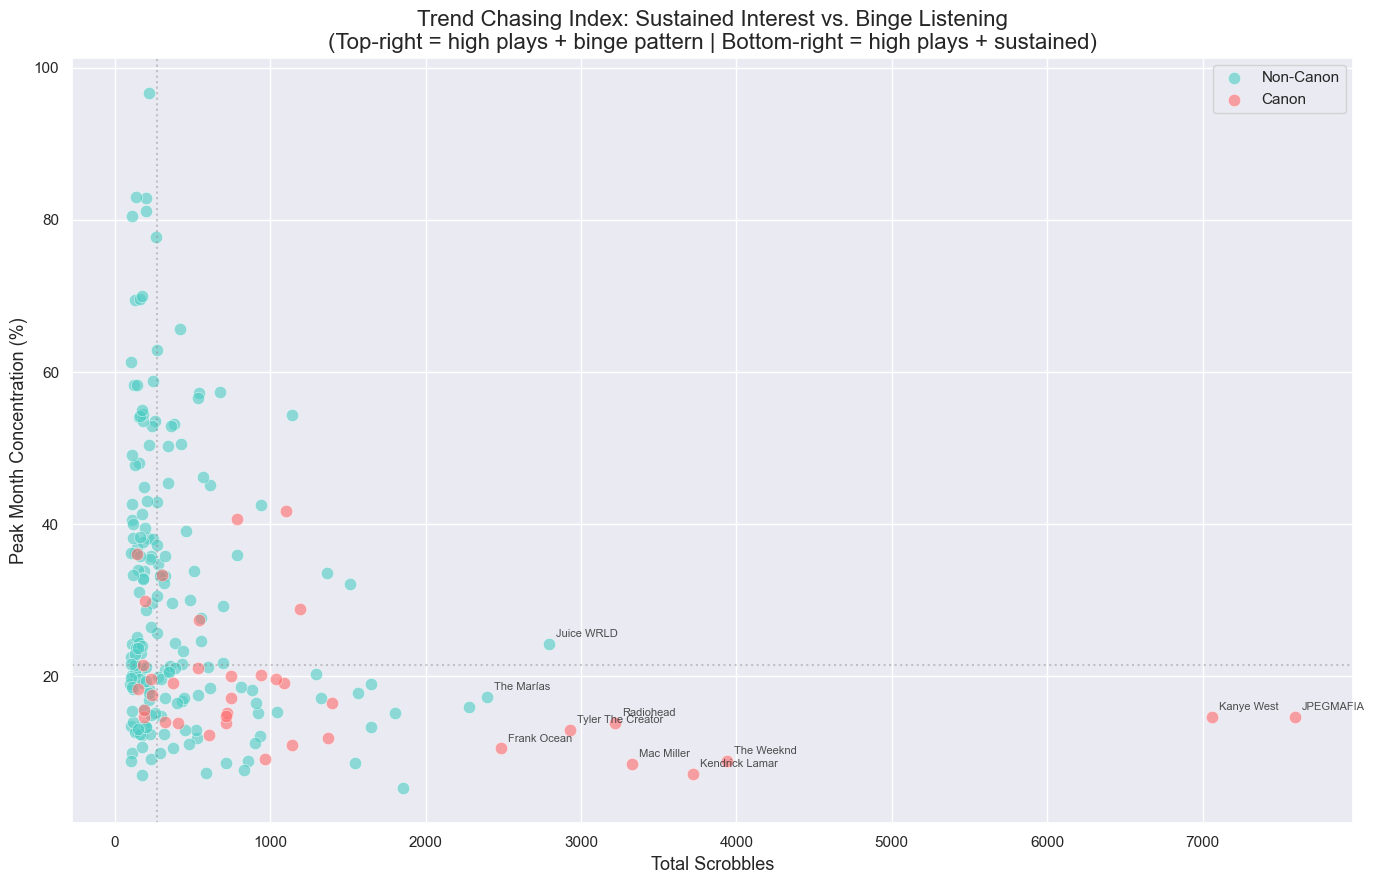

In [108]:
# Visualize trend chasing: scatter of total plays vs peak concentration
fig, ax = plt.subplots(figsize=(14, 9))

non_canon_t = trend_df[~trend_df['is_canon']]
canon_t = trend_df[trend_df['is_canon']]

ax.scatter(non_canon_t['total_plays'], non_canon_t['peak_concentration'] * 100,
           s=80, alpha=0.6, color='#4ECDC4', label='Non-Canon', edgecolors='white', linewidth=0.5)
ax.scatter(canon_t['total_plays'], canon_t['peak_concentration'] * 100,
           s=80, alpha=0.6, color='#FF6B6B', label='Canon', edgecolors='white', linewidth=0.5)

# Label notable artists
for _, row in trend_df.nlargest(10, 'total_plays').iterrows():
    ax.annotate(row['artist'], (row['total_plays'], row['peak_concentration'] * 100),
                fontsize=8, alpha=0.8, xytext=(5, 5), textcoords='offset points')

# Quadrant labels
median_plays = trend_df['total_plays'].median()
median_peak = trend_df['peak_concentration'].median() * 100
ax.axhline(y=median_peak, color='gray', linestyle=':', alpha=0.4)
ax.axvline(x=median_plays, color='gray', linestyle=':', alpha=0.4)

ax.set_xlabel('Total Scrobbles')
ax.set_ylabel('Peak Month Concentration (%)')
ax.set_title('Trend Chasing Index: Sustained Interest vs. Binge Listening\n'
             '(Top-right = high plays + binge pattern | Bottom-right = high plays + sustained)')
ax.legend()
plt.tight_layout()
plt.show()

### 4.4 Discovery Rate Over Time

Are you still finding new artists, or have you locked into an aesthetic and stopped exploring? A performative listener often "completes" their taste profile and stops discovering. An authentic listener keeps evolving.

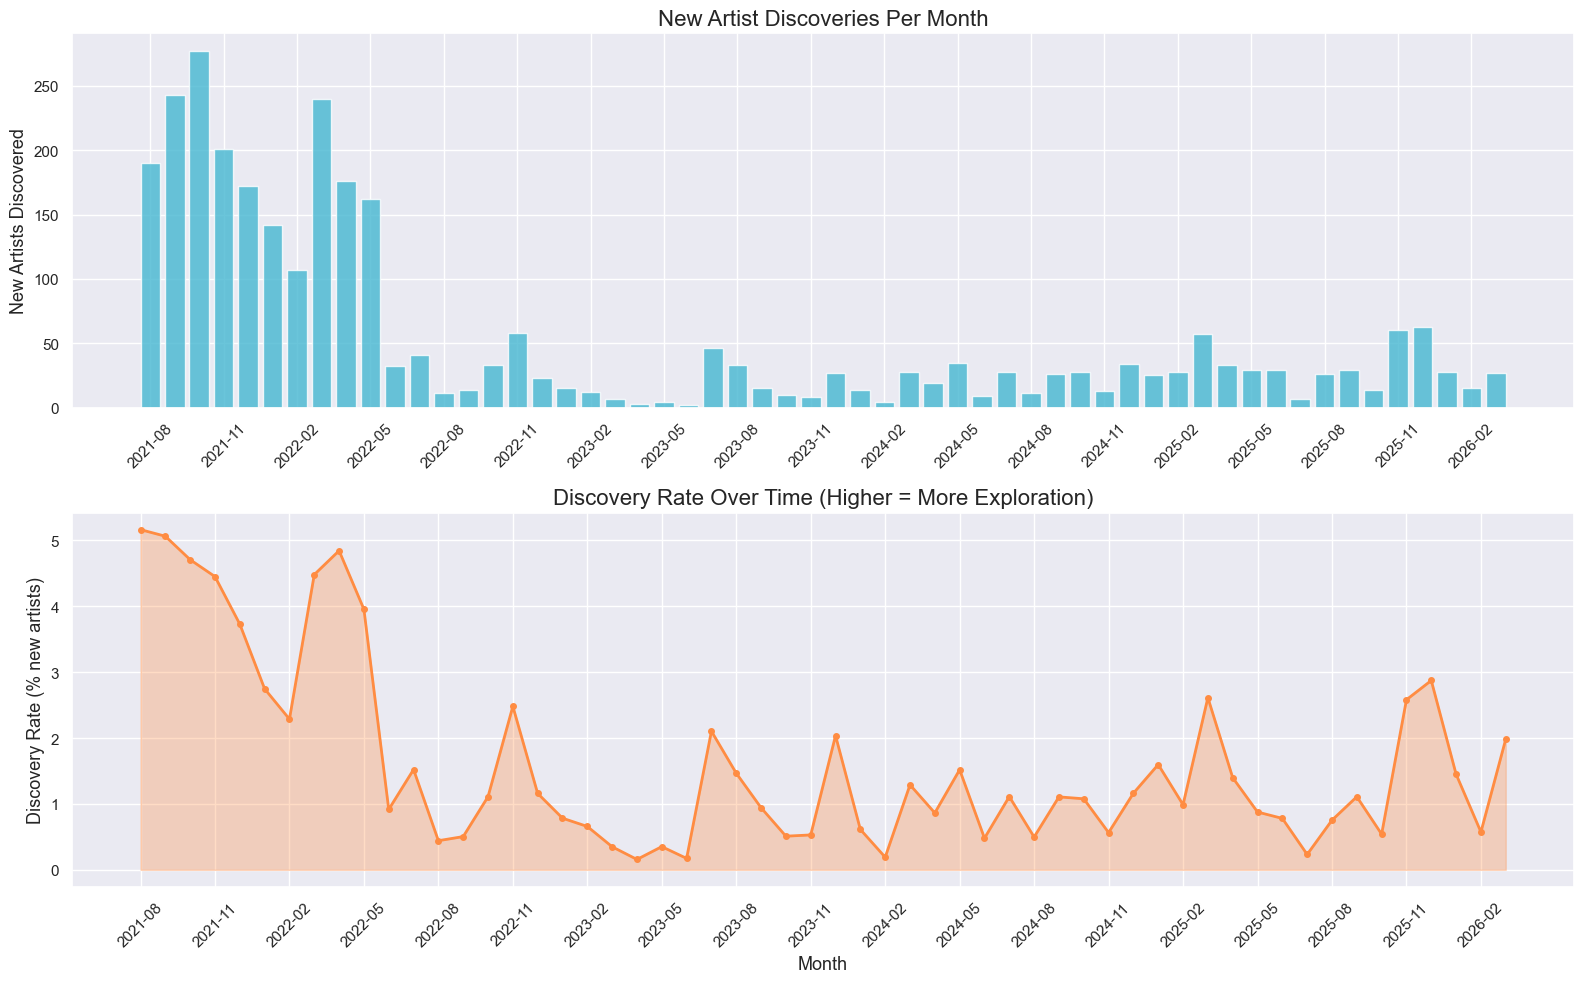


Avg discovery rate (first half): 2.06%
Avg discovery rate (second half): 1.17%
📉 Discovery rate is DECLINING — taste may be calcifying.


In [109]:
# Track when each artist was FIRST listened to
df_sorted = df.sort_values('timestamp')
first_listen = df_sorted.groupby('artist')['timestamp'].min().reset_index()
first_listen.columns = ['artist', 'first_listened']
first_listen['year_month'] = first_listen['first_listened'].dt.to_period('M')

# Count new artist discoveries per month
discoveries_per_month = first_listen.groupby('year_month').size().reset_index(name='new_artists')

# Also get total scrobbles per month for context
scrobbles_per_month = df.groupby('year_month').size().reset_index(name='total_scrobbles')
monthly_stats = discoveries_per_month.merge(scrobbles_per_month, on='year_month', how='outer').fillna(0)
monthly_stats['discovery_rate'] = monthly_stats['new_artists'] / monthly_stats['total_scrobbles'] * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# New artists per month
x = range(len(monthly_stats))
ax1.bar(x, monthly_stats['new_artists'], color='#45B7D1', alpha=0.8)
ax1.set_ylabel('New Artists Discovered')
ax1.set_title('New Artist Discoveries Per Month')
ax1.set_xticks(x[::3])
ax1.set_xticklabels([str(p) for p in monthly_stats['year_month'][::3]], rotation=45)

# Discovery rate (new artists as % of listening)
ax2.plot(x, monthly_stats['discovery_rate'], color='#FF8C42', linewidth=2, marker='o', markersize=4)
ax2.fill_between(x, monthly_stats['discovery_rate'], alpha=0.3, color='#FF8C42')
ax2.set_ylabel('Discovery Rate (% new artists)')
ax2.set_xlabel('Month')
ax2.set_title('Discovery Rate Over Time (Higher = More Exploration)')
ax2.set_xticks(x[::3])
ax2.set_xticklabels([str(p) for p in monthly_stats['year_month'][::3]], rotation=45)

plt.tight_layout()
plt.show()

# Trend: is discovery rate increasing or decreasing?
first_half = monthly_stats.head(len(monthly_stats)//2)['discovery_rate'].mean()
second_half = monthly_stats.tail(len(monthly_stats)//2)['discovery_rate'].mean()
print(f'\nAvg discovery rate (first half): {first_half:.2f}%')
print(f'Avg discovery rate (second half): {second_half:.2f}%')
if second_half < first_half * 0.7:
    print('📉 Discovery rate is DECLINING — taste may be calcifying.')
elif second_half > first_half * 1.1:
    print('📈 Discovery rate is INCREASING — still actively exploring.')
else:
    print('📊 Discovery rate is relatively STABLE.')

### 4.6 "Girl-Appeal" Performativity Index

A specific flavor of performative listening among guys: listening to artists primarily associated with female audiences or romantic/soft aesthetics — not necessarily because they love the music, but because it signals sensitivity, emotional depth, or a "good music taste" to women. Think artists like **Laufey, Keshi, Cigarettes After Sex, Daniel Caesar, TV Girl** — the kind of artists that end up on "boys who listen to [artist] are a green flag" TikToks.

This isn't saying enjoying these artists is fake — but if a guy's library is *disproportionately* loaded with these artists relative to the rest of their taste, it may signal performative curation.

In [110]:
# "Girl-Appeal" artists — artists guys listen to that signal
# sensitivity/good taste to women. Common on "green flag" TikToks.

girl_appeal = {
    # Soft/romantic male artists (the "he listens to X? marry him" tier)
    'Keshi', 'Daniel Caesar', 'Steve Lacy', 'Brent Faiyaz', 'Giveon',
    'Joji', 'Rex Orange County', 'Omar Apollo', 'Boy Pablo', 'Role Model',
    'Khalid', 'Miguel', '6LACK', 'Bryson Tiller', 'Aries',
    'Still Woozy', 'Surfaces', 'Dominic Fike', 'Wallows', 'Conan Gray',
    
    # Female/feminine artists guys listen to performatively
    'Taylor Swift', 'Sabrina Carpenter', 'Laufey', 'Lorde',
    'Billie Eilish', 'Olivia Rodrigo', 'SZA', 'Doja Cat',
    'Clairo', 'Phoebe Bridgers', 'Mitski', 'beabadoobee',
    'Faye Webster', 'Japanese Breakfast', 'mxmtoon',
    'Carly Rae Jepsen', 'Rina Sawayama', 'Jhené Aiko',
    'Summer Walker', 'Kehlani', 'Snoh Aalegra', 'Victoria Monét',
    'Kali Uchis', 'Alina Baraz', 'Raveena', 'Chloe x Halle',
    
    # "Aesthetic vibes" artists (the date-night playlist tier)
    'Cigarettes After Sex', 'TV Girl', 'The Marías', 'Men I Trust',
    'Magdalena Bay', 'FKA twigs', 'Chase Atlantic', 'Current Joys',
    'Verzache', 'wave to earth', 'PREP', 'Emotional Oranges',
    'The Neighbourhood', 'Tame Impala', 'Mac DeMarco',
    'Charli xcx', 'ROSALÍA', 'Dua Lipa'
}

# Calculate girl-appeal listening
df['is_girl_appeal'] = df['artist'].isin(girl_appeal)
girl_appeal_pct = df['is_girl_appeal'].mean() * 100
girl_appeal_scrobbles = df['is_girl_appeal'].sum()

# Which girl-appeal artists do you actually listen to?
girl_appeal_breakdown = df[df['is_girl_appeal']].groupby('artist').size().sort_values(ascending=False)

print(f'=== GIRL-APPEAL PERFORMATIVITY ===')
print(f'Total girl-appeal scrobbles: {girl_appeal_scrobbles:,} / {len(df):,} ({girl_appeal_pct:.1f}%)')
print(f'\nYour girl-appeal artists (ranked by plays):\n')
for artist, plays in girl_appeal_breakdown.items():
    print(f'  {artist}: {plays:,}')

if girl_appeal_pct > 30:
    print(f'\n⚠️  HIGH girl-appeal concentration ({girl_appeal_pct:.1f}%) — your library '
          f'reads like a \"boys who listen to this are a green flag\" starter pack.')
elif girl_appeal_pct > 15:
    print(f'\n📊 MODERATE girl-appeal ({girl_appeal_pct:.1f}%) — a noticeable chunk, but '
          f'balanced with other listening.')
else:
    print(f'\n✅ LOW girl-appeal ({girl_appeal_pct:.1f}%) — not a significant pattern.')


=== GIRL-APPEAL PERFORMATIVITY ===
Total girl-appeal scrobbles: 19,085 / 151,811 (12.6%)

Your girl-appeal artists (ranked by plays):

  The Marías: 2,392
  Magdalena Bay: 1,804
  Verzache: 1,565
  FKA twigs: 1,099
  Charli xcx: 1,089
  Clairo: 1,041
  Men I Trust: 920
  Mac DeMarco: 858
  Rina Sawayama: 717
  Billie Eilish: 714
  Joji: 694
  Chase Atlantic: 613
  Tame Impala: 606
  Dua Lipa: 587
  Dominic Fike: 543
  Doja Cat: 531
  Khalid: 479
  Steve Lacy: 389
  SZA: 322
  Rex Orange County: 238
  Laufey: 178
  ROSALÍA: 158
  Carly Rae Jepsen: 158
  Lorde: 147
  Aries: 144
  Daniel Caesar: 139
  Kali Uchis: 126
  Brent Faiyaz: 109
  beabadoobee: 108
  TV Girl: 102
  Japanese Breakfast: 82
  Miguel: 78
  Olivia Rodrigo: 72
  Taylor Swift: 55
  The Neighbourhood: 29
  Surfaces: 26
  Still Woozy: 26
  Alina Baraz: 24
  Jhené Aiko: 23
  Kehlani: 16
  Omar Apollo: 14
  Chloe x Halle: 12
  Bryson Tiller: 10
  Phoebe Bridgers: 10
  Cigarettes After Sex: 9
  Wallows: 7
  Faye Webster: 7
  S

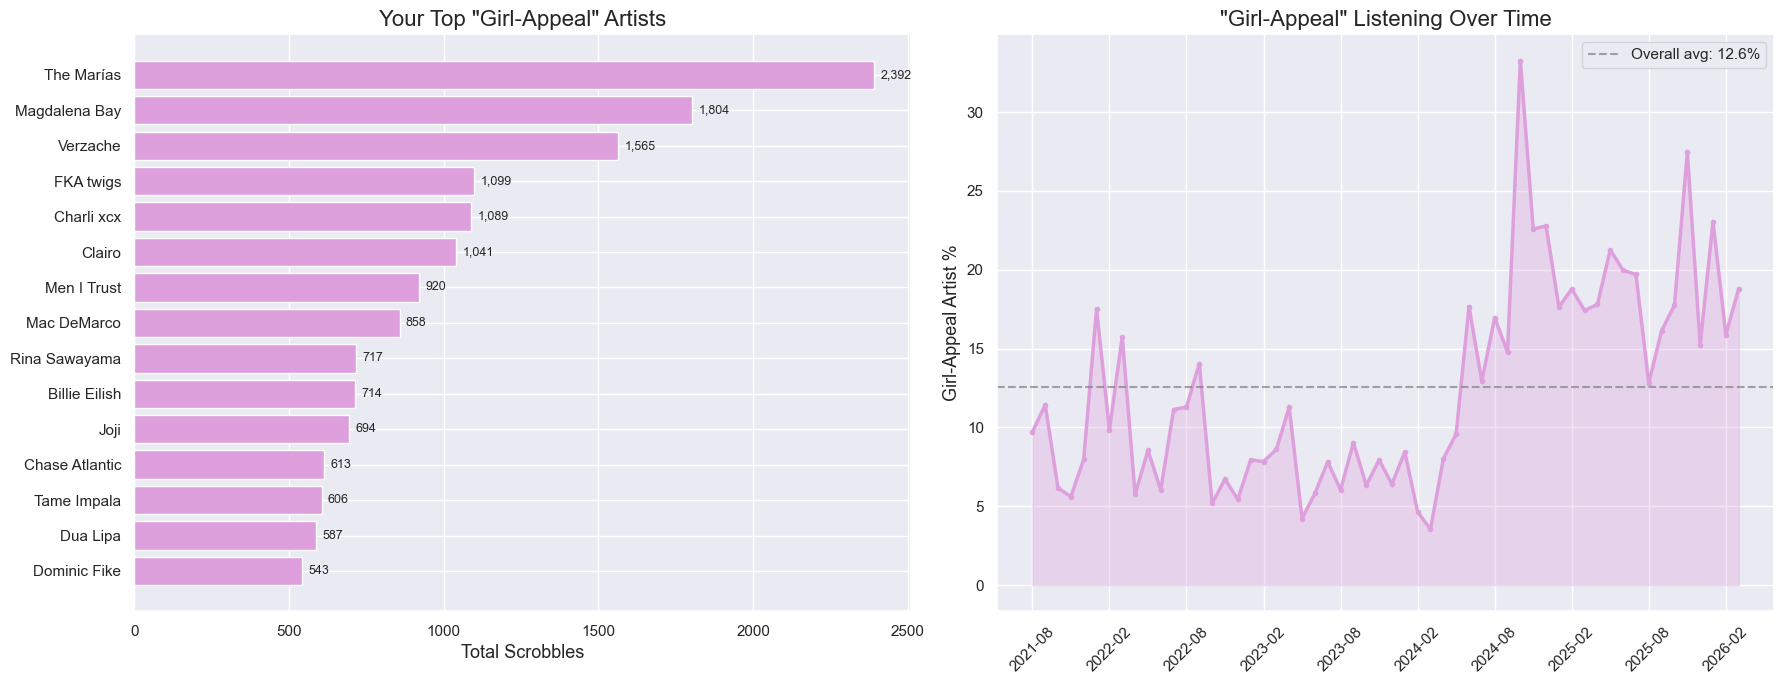

In [111]:
# Girl-appeal listening over time
girl_monthly = df.groupby(['year_month', 'is_girl_appeal']).size().unstack(fill_value=0)
girl_monthly.columns = ['Other', 'Girl-Appeal']
girl_monthly_pct = girl_monthly.div(girl_monthly.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart of top girl-appeal artists
top_ga = girl_appeal_breakdown.head(15)
ax1.barh(top_ga.index[::-1], top_ga.values[::-1], color='#DDA0DD', edgecolor='white')
ax1.set_xlabel('Total Scrobbles')
ax1.set_title('Your Top "Girl-Appeal" Artists')
for bar, val in zip(ax1.patches, top_ga.values[::-1]):
    ax1.text(val + 20, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)

# Girl-appeal % over time
x = range(len(girl_monthly_pct))
ax2.plot(x, girl_monthly_pct['Girl-Appeal'], color='#DDA0DD', linewidth=2.5, marker='o', markersize=3)
ax2.fill_between(x, girl_monthly_pct['Girl-Appeal'], alpha=0.3, color='#DDA0DD')
ax2.axhline(y=girl_appeal_pct, color='gray', linestyle='--', alpha=0.7, 
            label=f'Overall avg: {girl_appeal_pct:.1f}%')
ax2.set_ylabel('Girl-Appeal Artist %')
ax2.set_title('"Girl-Appeal" Listening Over Time')
ax2.legend()
ax2.set_xticks(x[::6])
ax2.set_xticklabels([str(p) for p in girl_monthly_pct.index[::6]], rotation=45)

plt.tight_layout()
plt.show()


### 4.7 "Drain Gang / Internet-Core" Performativity Index

Another distinct flavor of performative listening: the **Drain Gang / Sadboys / internet-core** aesthetic. Listening to Bladee, Ecco2k, Yung Lean, and adjacent artists doesn't just mean you like the music — it signals a specific online identity tied to irony, post-internet aesthetics, and being "plugged in" to underground internet culture.

This extends beyond Drain Gang itself to a broader ecosystem: hyperpop (100 gecs, SOPHIE), glitchcore (Machine Girl), SoundCloud experimentalism (Bones, $uicideboy$), and the "Fantano-approved underground" (Death Grips, JPEGMAFIA, Black Midi). If someone's library is loaded with these artists, it may signal curating an identity around being terminally online and avant-garde rather than genuinely diverse taste.

The performative version: *"I listen to Bladee"* becomes a personality trait rather than just a music preference.

In [112]:
# "Drain Gang / Internet-Core" artists — the terminally online,
# irony-pilled, avant-garde music identity signifiers

drain_internet = {
    # Drain Gang / Sadboys (the core)
    'Bladee', 'Ecco2k', 'Thaiboy Digital', 'Yung Lean', 'Whitearmor',
    'Adamn Killa', 'Drain Gang',
    
    # Hyperpop / glitchcore adjacent
    '100 gecs', 'SOPHIE', 'A.G. Cook', 'umru', 'Dylan Brady',
    'Laura Les', 'Alice Gas', 'Machine Girl', 'Food House',
    'underscores', 'Jane Remover', 'Frost Children', 'd0llywood1',
    
    # "Fantano-core" / internet-approved underground
    'Death Grips', 'JPEGMAFIA', 'Black Midi', 'Black Country, New Road',
    'Injury Reserve', 'clipping.', 'Daughters', 'Have a Nice Life',
    'Swans', 'Godspeed You! Black Emperor', 'Lingua Ignota',
    
    # SoundCloud underground / plugg / rage
    'Bones', '$uicideboy$', 'Night Lovell', 'Lil Ugly Mane',
    'Cities Aviv', 'Sematary', 'Haunted Mound',
    'Cartier God', 'Lancey Foux',
    
    # Internet-adjacent experimentalism
    'Arca', 'Oneohtrix Point Never', 'Iglooghost', 'Vegyn',
    'KAYTRANADA', 'Flume', 'Floating Points', 'Four Tet',
    'Aphex Twin', 'Boards of Canada', 'Flying Lotus',
    
    # Online-core / meme-adjacent artists
    'Yung Gravy', '100 gecs', 'Jack Stauber', 'Negative XP',
    'Sewerslvt', 'Lemon Demon', 'Will Wood',
    'Car Seat Headrest', 'Alex G', 'Duster',
    
    # The "I was into them before TikTok" crowd
    'Mk.gee', 'Quadeca', 'Genesis Owusu', 'Kenny Mason',
    'Denzel Curry', 'Freddie Gibbs', 'Earl Sweatshirt',
    'Billy Woods', 'Armand Hammer', 'MIKE', 'Navy Blue',
    'Boldy James', 'Mavi', 'Pink Siifu'
}

# Calculate drain/internet-core listening
df['is_drain'] = df['artist'].isin(drain_internet)
drain_pct = df['is_drain'].mean() * 100
drain_scrobbles = df['is_drain'].sum()

# Which drain/internet-core artists do you actually listen to?
drain_breakdown = df[df['is_drain']].groupby('artist').size().sort_values(ascending=False)

print(f'=== DRAIN / INTERNET-CORE PERFORMATIVITY ===')
print(f'Total drain/internet-core scrobbles: {drain_scrobbles:,} / {len(df):,} ({drain_pct:.1f}%)')
print(f'\nYour drain/internet-core artists (ranked by plays):\n')
for artist, plays in drain_breakdown.items():
    print(f'  {artist}: {plays:,}')

if drain_pct > 30:
    print(f'\n⚠️  HIGH drain/internet-core ({drain_pct:.1f}%) — your library is giving '
          f'\"I found this on a RateYourMusic chart at 3am\" energy.')
elif drain_pct > 15:
    print(f'\n📊 MODERATE drain/internet-core ({drain_pct:.1f}%) — you\'re plugged in '
          f'but it\'s not your whole identity.')
else:
    print(f'\n✅ LOW drain/internet-core ({drain_pct:.1f}%) — not a terminally online listener.')


=== DRAIN / INTERNET-CORE PERFORMATIVITY ===
Total drain/internet-core scrobbles: 18,539 / 151,811 (12.2%)

Your drain/internet-core artists (ranked by plays):

  JPEGMAFIA: 7,596
  Denzel Curry: 1,369
  Freddie Gibbs: 1,138
  Injury Reserve: 1,039
  Quadeca: 911
  Genesis Owusu: 880
  Yung Lean: 814
  Flying Lotus: 787
  Bladee: 552
  Earl Sweatshirt: 535
  Swans: 438
  underscores: 399
  100 gecs: 321
  Death Grips: 306
  Jane Remover: 247
  Pink Siifu: 219
  Armand Hammer: 197
  clipping.: 171
  Godspeed You! Black Emperor: 158
  KAYTRANADA: 127
  Lil Ugly Mane: 80
  Aphex Twin: 72
  Flume: 66
  Car Seat Headrest: 44
  Jack Stauber: 17
  Thaiboy Digital: 14
  Mk.gee: 8
  Arca: 8
  Whitearmor: 7
  umru: 5
  Vegyn: 4
  Alex G: 2
  Have a Nice Life: 2
  Boards of Canada: 1
  Lancey Foux: 1
  Duster: 1
  Sematary: 1
  Drain Gang: 1
  Iglooghost: 1

✅ LOW drain/internet-core (12.2%) — not a terminally online listener.


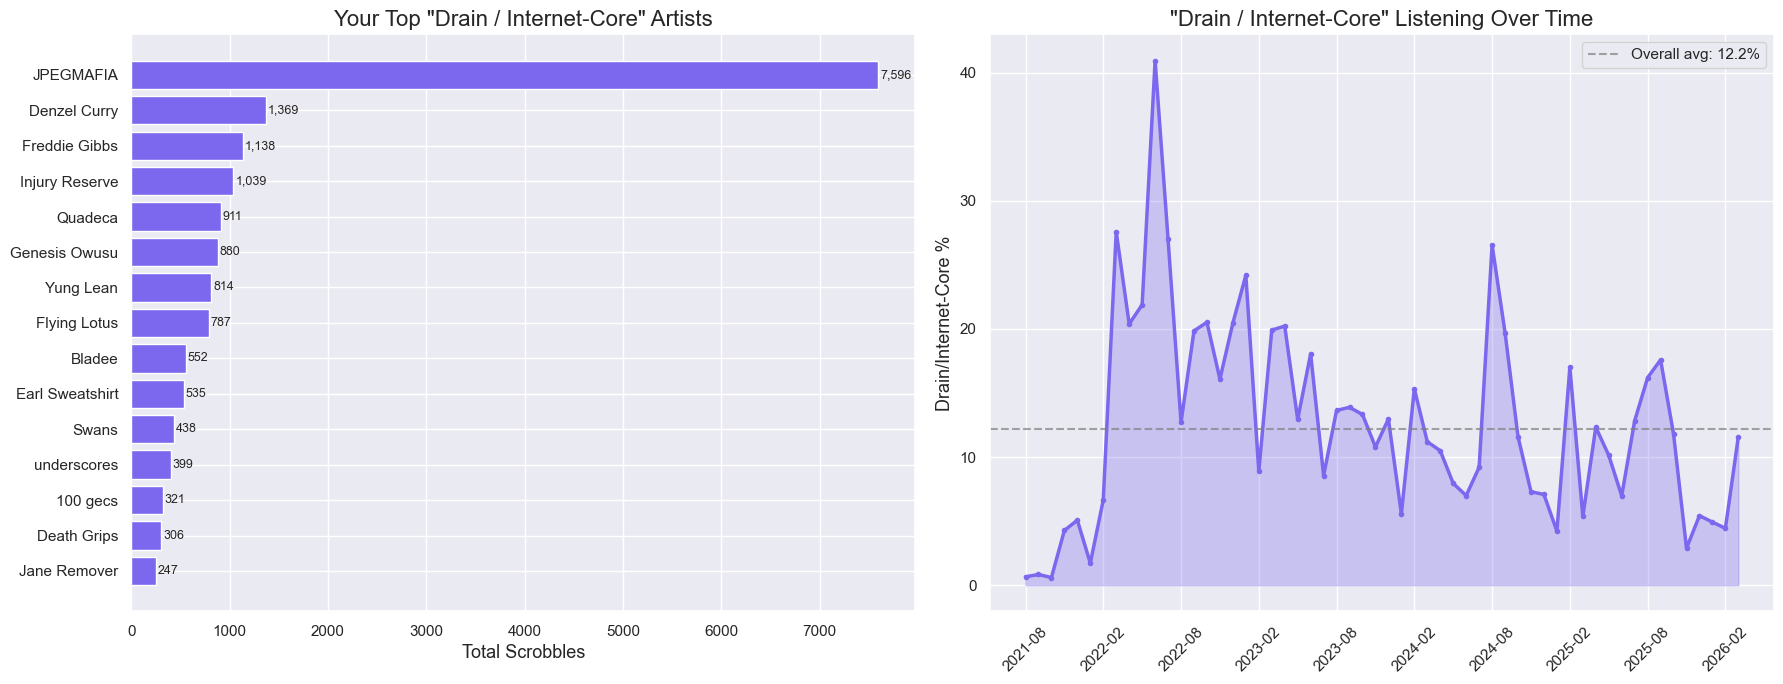

In [113]:
# Drain/internet-core listening over time
drain_monthly = df.groupby(['year_month', 'is_drain']).size().unstack(fill_value=0)
drain_monthly.columns = ['Other', 'Drain/Internet-Core']
drain_monthly_pct = drain_monthly.div(drain_monthly.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart of top drain artists
top_drain = drain_breakdown.head(15)
ax1.barh(top_drain.index[::-1], top_drain.values[::-1], color='#7B68EE', edgecolor='white')
ax1.set_xlabel('Total Scrobbles')
ax1.set_title('Your Top "Drain / Internet-Core" Artists')
for bar, val in zip(ax1.patches, top_drain.values[::-1]):
    ax1.text(val + 20, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)

# Drain % over time
x = range(len(drain_monthly_pct))
ax2.plot(x, drain_monthly_pct['Drain/Internet-Core'], color='#7B68EE', linewidth=2.5, marker='o', markersize=3)
ax2.fill_between(x, drain_monthly_pct['Drain/Internet-Core'], alpha=0.3, color='#7B68EE')
ax2.axhline(y=drain_pct, color='gray', linestyle='--', alpha=0.7,
            label=f'Overall avg: {drain_pct:.1f}%')
ax2.set_ylabel('Drain/Internet-Core %')
ax2.set_title('"Drain / Internet-Core" Listening Over Time')
ax2.legend()
ax2.set_xticks(x[::6])
ax2.set_xticklabels([str(p) for p in drain_monthly_pct.index[::6]], rotation=45)

plt.tight_layout()
plt.show()


### 4.8 "Tough Guy Rap" Performativity Index

The flip side of girl-appeal performativity: guys who **exclusively** listen to aggressive rap, drill, trap, and gangsta rap to project toughness and masculinity. This isn't about liking rap — it's about using a hyper-aggressive library as an identity signal.

The performative version: refusing to listen to anything outside hard rap because softer music would compromise the image. The library is all **Playboi Carti, Future, Chief Keef, NBA YoungBoy, 21 Savage** — zero vulnerability, zero genre diversity. Every playlist is "gym music" or "late night drives."

Signs of tough-guy rap performativity:
- Library dominated by trap, drill, and aggressive rap with almost nothing else
- Won't listen to female artists, indie, or anything "soft"
- Music taste is essentially a curated tough-guy persona rather than genuine exploration

Again — listening to hard rap doesn't make someone performative. But if it's *all* someone listens to while avoiding anything outside that lane, it may signal identity curation over genuine taste.

In [114]:
# "Tough Guy Rap" artists — aggressive rap, drill, trap artists
# associated with projecting masculinity and toughness

tough_rap = {
    # Trap / hard rap (the gym playlist core)
    'Playboi Carti', 'Future', 'Young Thug', 'Lil Uzi Vert',
    'Travis Scott', '21 Savage', 'Metro Boomin', 'Gunna',
    'Lil Baby', 'Migos', 'Offset', 'Quavo', 'Takeoff',
    'Gucci Mane', '2 Chainz', 'Rae Sremmurd', 'Swae Lee',
    
    # Drill (Chicago, UK, NY)
    'Chief Keef', 'Lil Durk', 'King Von', 'G Herbo',
    'Polo G', 'Fredo Bang', 'Pop Smoke', 'Fivio Foreign',
    'Sheff G', 'Sleepy Hallow', 'Kay Flock', 'Lil Tjay',
    'Central Cee', 'Digga D', 'Headie One', 'Tion Wayne',
    
    # Rage / aggro rap
    'Trippie Redd', 'XXXTENTACION', 'Ski Mask the Slump God',
    'Zillakami', 'City Morgue', 'Sosmula', 'scarlxrd',
    'Jasiah', 'SoFaygo', 'Ken Carson', 'Destroy Lonely',
    
    # Gangsta / street rap
    'NBA YoungBoy', 'Kodak Black', 'Moneybagg Yo', 'EST Gee',
    'Pooh Shiesty', 'Lil Loaded', '42 Dugg', 'Babyface Ray',
    'Rio Da Yung OG', 'BabyTron',
    
    # Hard-image mainstream rap
    'Drake', 'DaBaby', 'Lil Pump', 'Smokepurpp', 'Comethazine',
    'NLE Choppa', 'Blueface', 'YG', 'Tyga', 'Tee Grizzley',
    
    # OG hard rap (the "real hip-hop" tough guys)
    'DMX', '50 Cent', 'Eminem', 'Dr. Dre', 'Ice Cube',
    'Mobb Deep', 'Wu-Tang Clan', 'Jadakiss', 'Styles P',
    'Jeezy', 'T.I.', 'Meek Mill', 'Rick Ross',
    
    # Griselda / street luxury
    'Westside Gunn', 'Conway the Machine', 'Benny the Butcher'
}

# Calculate tough-rap listening
df['is_tough_rap'] = df['artist'].isin(tough_rap)
tough_rap_pct = df['is_tough_rap'].mean() * 100
tough_rap_scrobbles = df['is_tough_rap'].sum()

# Which tough-rap artists do you actually listen to?
tough_breakdown = df[df['is_tough_rap']].groupby('artist').size().sort_values(ascending=False)

print(f'=== TOUGH GUY RAP PERFORMATIVITY ===')
print(f'Total tough-rap scrobbles: {tough_rap_scrobbles:,} / {len(df):,} ({tough_rap_pct:.1f}%)')
print(f'\nYour tough-rap artists (ranked by plays):\n')
for artist, plays in tough_breakdown.items():
    print(f'  {artist}: {plays:,}')

# Compare tough-rap % vs girl-appeal % — the "masculinity balance"
print(f'\n--- MASCULINITY BALANCE CHECK ---')
print(f'  Tough-rap listening:   {tough_rap_pct:.1f}%')
print(f'  Girl-appeal listening: {girl_appeal_pct:.1f}%')
ratio = tough_rap_pct / max(girl_appeal_pct, 0.1)
if ratio > 3:
    print(f'  Ratio: {ratio:.1f}x — ⚠️ HEAVILY skewed toward tough-rap. '
          f'Your library is giving \"I don\'t listen to soft music\" energy.')
elif ratio > 1.5:
    print(f'  Ratio: {ratio:.1f}x — leans tough but not extreme.')
elif ratio > 0.5:
    print(f'  Ratio: {ratio:.1f}x — ✅ balanced between hard and soft.')
else:
    print(f'  Ratio: {ratio:.1f}x — leans more toward the soft/girl-appeal side.')

if tough_rap_pct > 40:
    print(f'\n⚠️  HIGH tough-rap concentration ({tough_rap_pct:.1f}%) — your library is '
          f'basically a gym playlist that never ends.')
elif tough_rap_pct > 20:
    print(f'\n📊 MODERATE tough-rap ({tough_rap_pct:.1f}%) — you enjoy hard rap '
          f'but it\'s not your whole identity.')
else:
    print(f'\n✅ LOW tough-rap ({tough_rap_pct:.1f}%) — not performing toughness through music.')


=== TOUGH GUY RAP PERFORMATIVITY ===
Total tough-rap scrobbles: 12,598 / 151,811 (8.3%)

Your tough-rap artists (ranked by plays):

  Travis Scott: 2,280
  Drake: 1,852
  XXXTENTACION: 1,647
  Trippie Redd: 1,512
  Lil Uzi Vert: 931
  Ski Mask the Slump God: 784
  Playboi Carti: 714
  SoFaygo: 448
  Metro Boomin: 356
  Young Thug: 350
  Westside Gunn: 315
  Future: 272
  Dr. Dre: 207
  Eminem: 177
  Lil Baby: 172
  21 Savage: 171
  Kodak Black: 115
  Polo G: 56
  Migos: 46
  Meek Mill: 37
  Offset: 30
  Benny the Butcher: 21
  G Herbo: 20
  Tyga: 15
  50 Cent: 13
  Conway the Machine: 10
  DaBaby: 9
  Ken Carson: 5
  Central Cee: 4
  Takeoff: 4
  Fivio Foreign: 4
  Chief Keef: 3
  Ice Cube: 3
  Gunna: 3
  Rick Ross: 2
  Jasiah: 2
  Gucci Mane: 2
  Wu-Tang Clan: 2
  Smokepurpp: 1
  Lil Pump: 1
  Headie One: 1
  Lil Durk: 1

--- MASCULINITY BALANCE CHECK ---
  Tough-rap listening:   8.3%
  Girl-appeal listening: 12.6%
  Ratio: 0.7x — ✅ balanced between hard and soft.

✅ LOW tough-rap (8.

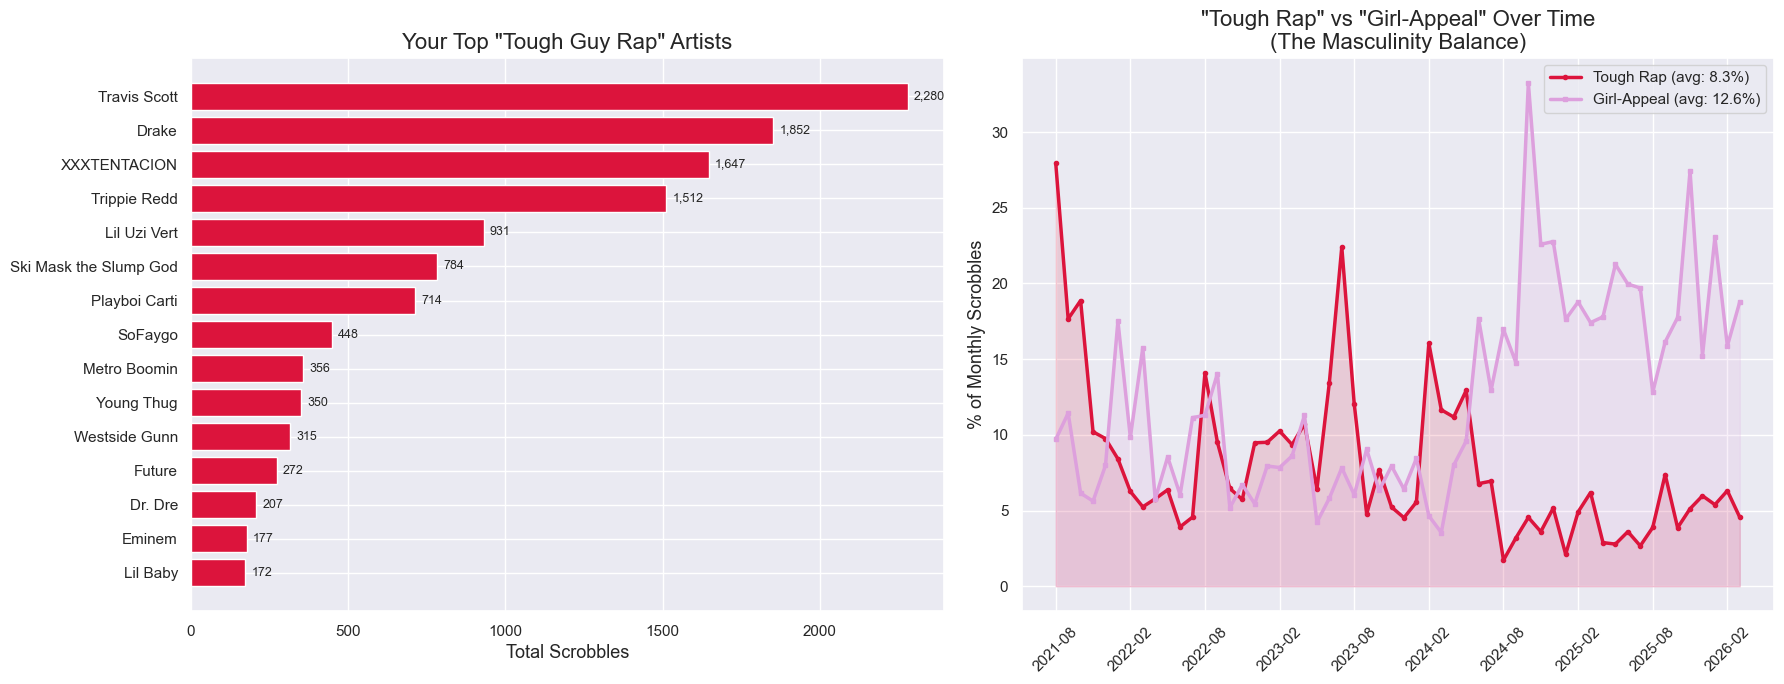

In [115]:
# Tough-rap listening over time + comparison with girl-appeal
tough_monthly = df.groupby(['year_month', 'is_tough_rap']).size().unstack(fill_value=0)
tough_monthly.columns = ['Other', 'Tough Rap']
tough_monthly_pct = tough_monthly.div(tough_monthly.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart of top tough-rap artists
top_tough = tough_breakdown.head(15)
ax1.barh(top_tough.index[::-1], top_tough.values[::-1], color='#DC143C', edgecolor='white')
ax1.set_xlabel('Total Scrobbles')
ax1.set_title('Your Top "Tough Guy Rap" Artists')
for bar, val in zip(ax1.patches, top_tough.values[::-1]):
    ax1.text(val + 20, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)

# Compare tough-rap vs girl-appeal over time
x = range(len(tough_monthly_pct))
ax2.plot(x, tough_monthly_pct['Tough Rap'], color='#DC143C', linewidth=2.5,
         marker='o', markersize=3, label=f'Tough Rap (avg: {tough_rap_pct:.1f}%)')
ax2.plot(x, girl_monthly_pct['Girl-Appeal'], color='#DDA0DD', linewidth=2.5,
         marker='s', markersize=3, label=f'Girl-Appeal (avg: {girl_appeal_pct:.1f}%)')
ax2.fill_between(x, tough_monthly_pct['Tough Rap'], alpha=0.15, color='#DC143C')
ax2.fill_between(x, girl_monthly_pct['Girl-Appeal'], alpha=0.15, color='#DDA0DD')
ax2.set_ylabel('% of Monthly Scrobbles')
ax2.set_title('"Tough Rap" vs "Girl-Appeal" Over Time\n(The Masculinity Balance)')
ax2.legend()
ax2.set_xticks(x[::6])
ax2.set_xticklabels([str(p) for p in tough_monthly_pct.index[::6]], rotation=45)

plt.tight_layout()
plt.show()


### 4.9 Combined Performativity Tier Breakdown

Now that we've defined all our performativity categories — Critical Canon, Girl-Appeal, Drain/Internet-Core, and Tough Guy Rap — let's see how **every single scrobble** breaks down. Each artist is assigned to their primary performativity tier (if they fit multiple, the most specific one wins), giving us a complete picture of what's driving the listening library.


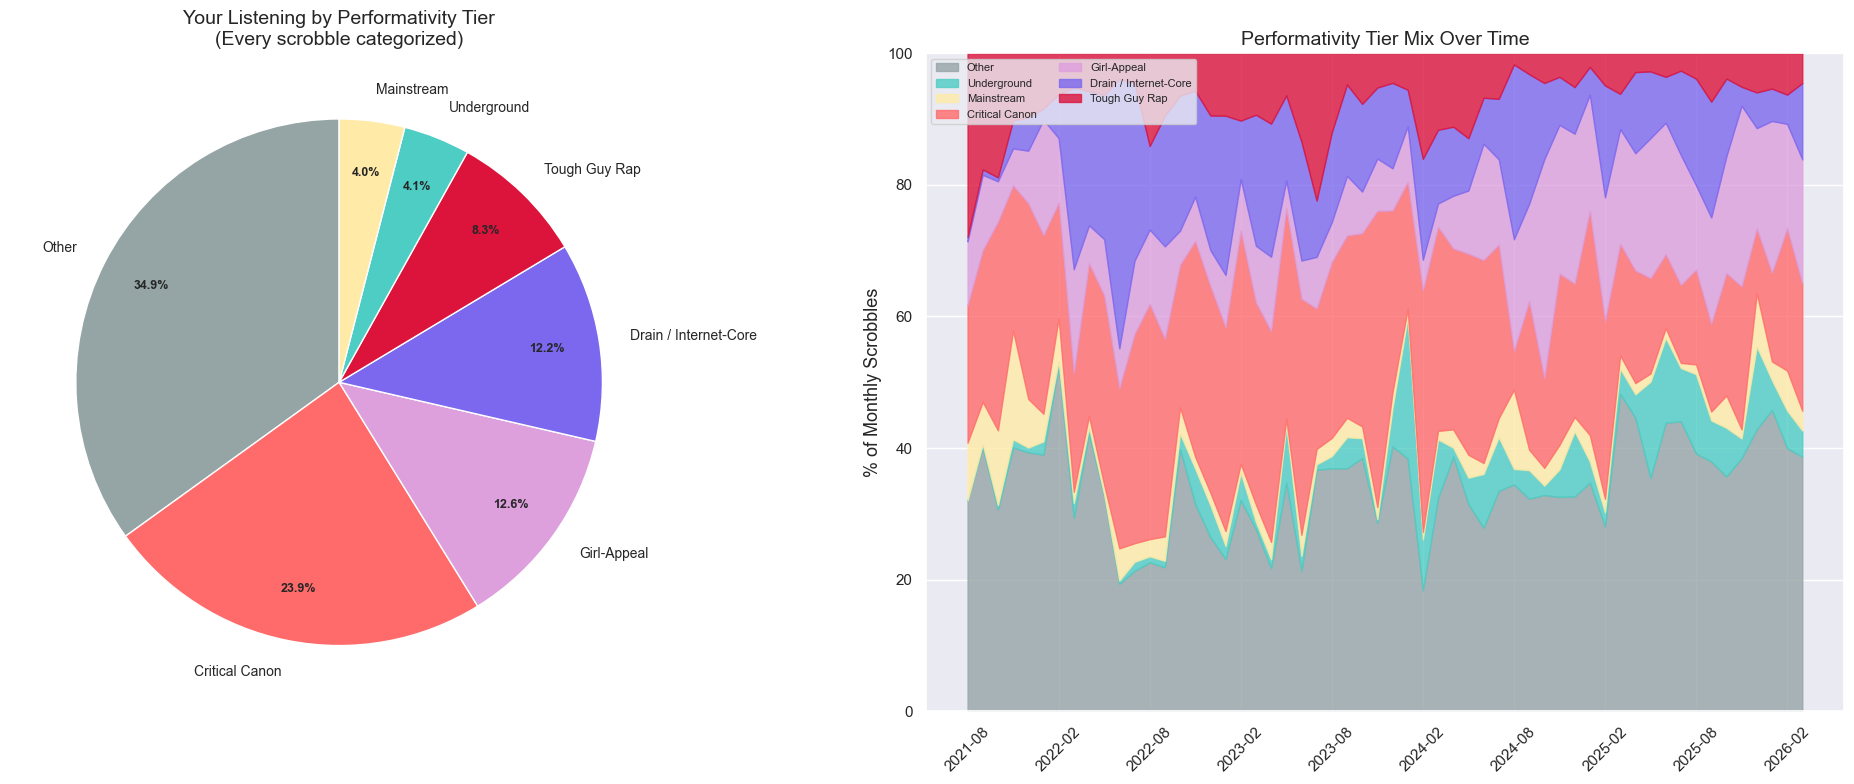


=== PERFORMATIVITY TIER BREAKDOWN ===

  Other                      53,039 scrobbles  ( 34.9%)
  Critical Canon             36,258 scrobbles  ( 23.9%)
  Girl-Appeal                19,085 scrobbles  ( 12.6%)
  Drain / Internet-Core      18,539 scrobbles  ( 12.2%)
  Tough Guy Rap              12,598 scrobbles  (  8.3%)
  Underground                 6,193 scrobbles  (  4.1%)
  Mainstream                  6,099 scrobbles  (  4.0%)
  -------------------------  ----------------  -------
  TOTAL                      151,811 scrobbles  (100.0%)

  Total "performative" listening: 57.0%
  Total "neutral" listening: 43.0%


In [116]:
# Define mainstream and underground tiers
# (These were used in the original analysis and are needed for the combined chart)

mainstream = {
    'Drake', 'The Weeknd', 'Kanye West', 'Travis Scott', 'Post Malone',
    'Billie Eilish', 'Doja Cat', 'Lil Uzi Vert', 'Juice WRLD', 'XXXTENTACION',
    'Daft Punk', 'Gorillaz', 'The Chainsmokers', 'Charli xcx', 'Playboi Carti',
    'Lil Baby', 'Future', '21 Savage', 'Bad Bunny', 'Trippie Redd',
    'Logic', 'J. Cole', 'Childish Gambino', 'Khalid', 'Frank Ocean',
    'Tyler The Creator', 'Kendrick Lamar', 'SZA', 'Metro Boomin',
    'Mac Miller', 'A$AP Rocky', 'Lorde', 'twenty one pilots'
}

underground = {
    'JPEGMAFIA', 'Injury Reserve', 'Westside Gunn', 'BROCKHAMPTON',
    'Verzache', 'C418', 'Kero Kero Bonito', 'Magdalena Bay',
    'Men I Trust', 'Yung Lean', 'Flying Lotus', 'Genesis Owusu',
    'Death Grips', 'Machine Girl', 'Black Midi', 'underscores',
    'Mk.gee', 'YONLAPA', 'Quadeca', 'Vegyn', 'SOPHIE',
    'Aphex Twin', 'Boards of Canada', 'King Krule',
    'Earl Sweatshirt', 'Billy Woods', 'Armand Hammer', 'MIKE',
    'Boldy James', 'Joey Valence & Brae', 'Saba', 'Freddie Gibbs'
}

# Categorize ALL artists into performativity tiers
# Priority order: if an artist falls into multiple categories,
# they get assigned to the FIRST matching one

def categorize_artist(artist):
    if artist in tough_rap:
        return 'Tough Guy Rap'
    elif artist in drain_internet:
        return 'Drain / Internet-Core'
    elif artist in girl_appeal:
        return 'Girl-Appeal'
    elif artist in critical_canon:
        return 'Critical Canon'
    elif artist in mainstream:
        return 'Mainstream'
    elif artist in underground:
        return 'Underground'
    else:
        return 'Other'

df['performativity_tier'] = df['artist'].apply(categorize_artist)

tier_counts = df['performativity_tier'].value_counts()
tier_pcts = df['performativity_tier'].value_counts(normalize=True) * 100

# Color palette for each tier
tier_colors = {
    'Tough Guy Rap': '#DC143C',
    'Drain / Internet-Core': '#7B68EE',
    'Girl-Appeal': '#DDA0DD',
    'Critical Canon': '#FF6B6B',
    'Mainstream': '#FFEAA7',
    'Underground': '#4ECDC4',
    'Other': '#95A5A6'
}

colors_ordered = [tier_colors[t] for t in tier_counts.index]

# === COMBINED PIE CHART ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Pie chart with all tiers
wedges, texts, autotexts = ax1.pie(
    tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
    colors=colors_ordered, startangle=90, textprops={'fontsize': 10},
    pctdistance=0.8, labeldistance=1.12
)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
ax1.set_title('Your Listening by Performativity Tier\n(Every scrobble categorized)', fontsize=14)

# Stacked bar showing tier breakdown over time
tier_monthly = df.groupby(['year_month', 'performativity_tier']).size().unstack(fill_value=0)
tier_monthly_pct = tier_monthly.div(tier_monthly.sum(axis=1), axis=0) * 100

# Plot order (bottom to top)
plot_order = ['Other', 'Underground', 'Mainstream', 'Critical Canon',
              'Girl-Appeal', 'Drain / Internet-Core', 'Tough Guy Rap']
plot_order = [t for t in plot_order if t in tier_monthly_pct.columns]

x = range(len(tier_monthly_pct))
bottom = np.zeros(len(tier_monthly_pct))
for tier in plot_order:
    if tier in tier_monthly_pct.columns:
        vals = tier_monthly_pct[tier].values
        ax2.fill_between(x, bottom, bottom + vals, alpha=0.8,
                        color=tier_colors[tier], label=tier)
        bottom += vals

ax2.set_ylabel('% of Monthly Scrobbles')
ax2.set_title('Performativity Tier Mix Over Time', fontsize=14)
ax2.legend(loc='upper left', fontsize=8, ncol=2)
ax2.set_xticks(list(x)[::6])
ax2.set_xticklabels([str(p) for p in tier_monthly_pct.index[::6]], rotation=45)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Print summary table
print('\n=== PERFORMATIVITY TIER BREAKDOWN ===\n')
for tier, count in tier_counts.items():
    pct = tier_pcts[tier]
    print(f'  {tier:25s}  {count:>6,} scrobbles  ({pct:5.1f}%)')
print(f'  {"":-<25s}  {"":-<6s}----------  -------')
print(f'  {"TOTAL":25s}  {len(df):>6,} scrobbles  (100.0%)')

# Performative vs non-performative split
perf_categories = {'Tough Guy Rap', 'Drain / Internet-Core', 'Girl-Appeal', 'Critical Canon'}
perf_pct = tier_pcts[[t for t in perf_categories if t in tier_pcts.index]].sum()
print(f'\n  Total "performative" listening: {perf_pct:.1f}%')
print(f'  Total "neutral" listening: {100 - perf_pct:.1f}%')


## 5. Listening Habits Deep Dive

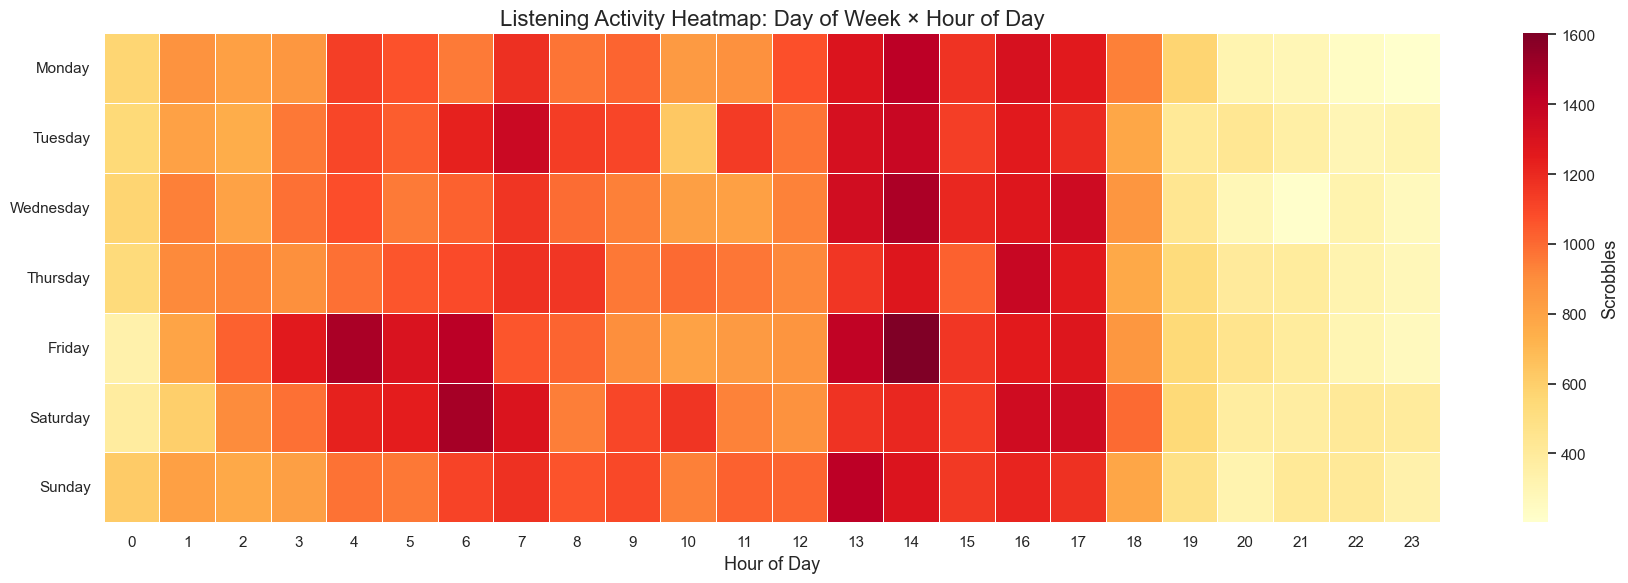

In [117]:
# When do you listen to music? (Heatmap by day of week and hour)
heatmap_data = df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)

# Reorder days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(day_order)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Scrobbles'})
ax.set_title('Listening Activity Heatmap: Day of Week × Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

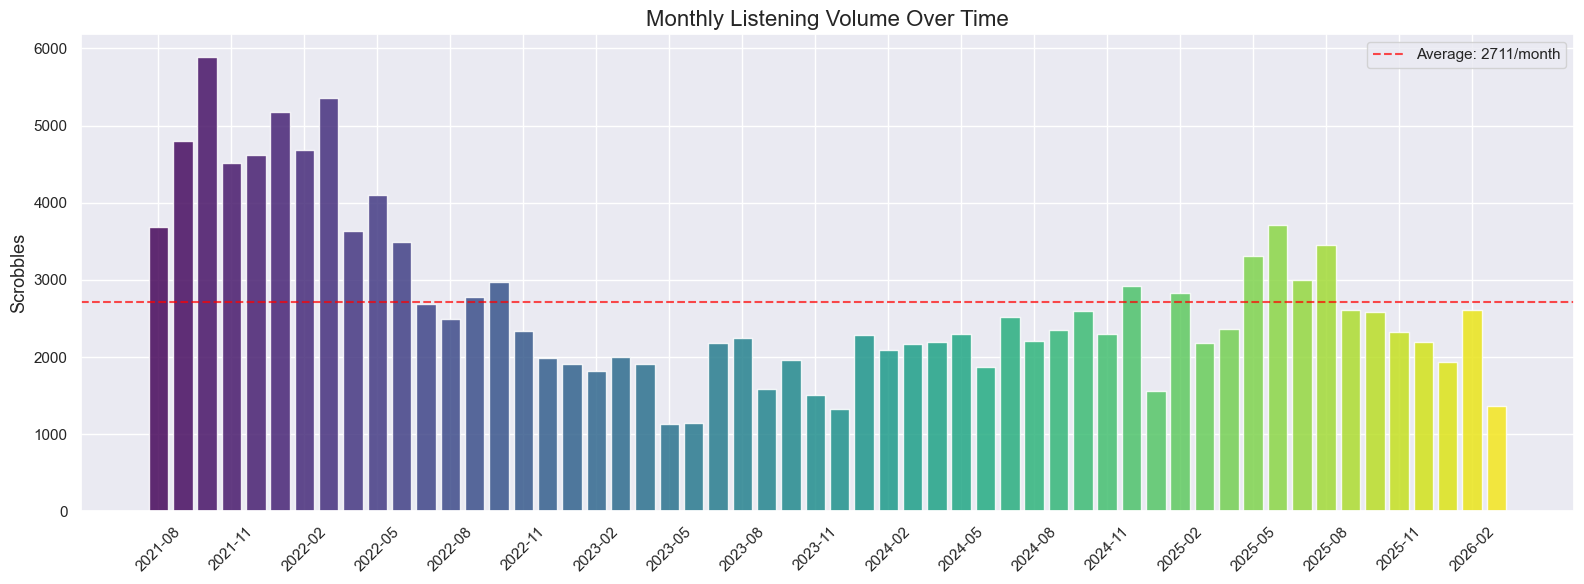

In [118]:
# Monthly scrobble volume over time
monthly_volume = df.groupby('year_month').size()

fig, ax = plt.subplots(figsize=(16, 6))
x = range(len(monthly_volume))
ax.bar(x, monthly_volume.values, color=sns.color_palette('viridis', len(monthly_volume)), alpha=0.85)
ax.set_ylabel('Scrobbles')
ax.set_title('Monthly Listening Volume Over Time')
ax.set_xticks(x[::3])
ax.set_xticklabels([str(p) for p in monthly_volume.index[::3]], rotation=45)

avg_monthly = monthly_volume.mean()
ax.axhline(y=avg_monthly, color='red', linestyle='--', alpha=0.7, label=f'Average: {avg_monthly:.0f}/month')
ax.legend()
plt.tight_layout()
plt.show()

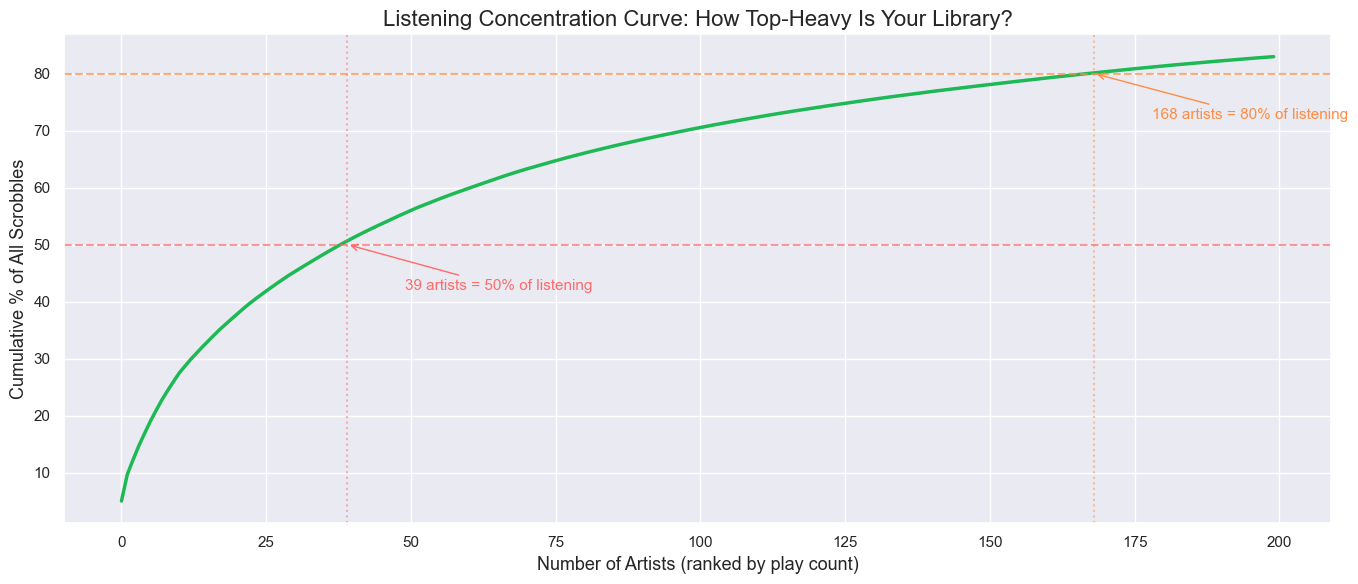

Total unique artists: 3,023
Artists making up 50% of listening: 39 (1.3%)
Artists making up 80% of listening: 168 (5.6%)


In [119]:
# Artist loyalty: How many artists make up 50% and 80% of all listening?
artist_counts = df['artist'].value_counts()
cumulative_pct = artist_counts.cumsum() / artist_counts.sum() * 100

artists_for_50 = (cumulative_pct <= 50).sum() + 1
artists_for_80 = (cumulative_pct <= 80).sum() + 1

fig, ax = plt.subplots(figsize=(14, 6))
x = range(min(200, len(cumulative_pct)))
ax.plot(x, cumulative_pct.values[:200], color='#1DB954', linewidth=2.5)
ax.axhline(y=50, color='#FF6B6B', linestyle='--', alpha=0.7)
ax.axhline(y=80, color='#FF8C42', linestyle='--', alpha=0.7)
ax.axvline(x=artists_for_50, color='#FF6B6B', linestyle=':', alpha=0.5)
ax.axvline(x=artists_for_80, color='#FF8C42', linestyle=':', alpha=0.5)

ax.annotate(f'{artists_for_50} artists = 50% of listening', 
            xy=(artists_for_50, 50), fontsize=11, color='#FF6B6B',
            xytext=(artists_for_50 + 10, 42), arrowprops=dict(arrowstyle='->', color='#FF6B6B'))
ax.annotate(f'{artists_for_80} artists = 80% of listening',
            xy=(artists_for_80, 80), fontsize=11, color='#FF8C42',
            xytext=(artists_for_80 + 10, 72), arrowprops=dict(arrowstyle='->', color='#FF8C42'))

ax.set_xlabel('Number of Artists (ranked by play count)')
ax.set_ylabel('Cumulative % of All Scrobbles')
ax.set_title('Listening Concentration Curve: How Top-Heavy Is Your Library?')
plt.tight_layout()
plt.show()

print(f'Total unique artists: {df.artist.nunique():,}')
print(f'Artists making up 50% of listening: {artists_for_50} ({artists_for_50/df.artist.nunique()*100:.1f}%)')
print(f'Artists making up 80% of listening: {artists_for_80} ({artists_for_80/df.artist.nunique()*100:.1f}%)')

## 6. Composite Performativity Score

Now we combine all factors into a single **Performativity Score** (0–100).

| Component | Weight | Reasoning |
|-----------|--------|-----------|
| Canon Overlap | 10% | High overlap with critical consensus = curated taste |
| Listening Depth | 15% | Only playing hits = surface engagement |
| Trend Chasing | 10% | Binge-drop patterns = following trends |
| Discovery Decline | 5% | Stopped exploring = locked-in aesthetic |
| Mainstream Concentration | 5% | Extreme mainstream/underground avoidance = performing |
| Girl-Appeal Index | 20% | High concentration of "green flag" artists = curating for romantic appeal |
| Drain/Internet-Core | 15% | High concentration of online-identity artists = terminally online curation |
| Tough Guy Rap | 20% | Aggressive rap dominating library = performing masculinity |


In [120]:
# Calculate each component score (0-100 scale, higher = more performative)

# 1. Canon Overlap Score
canon_score = min(canon_pct / 70 * 100, 100)  # 70%+ canon = max performative

# 2. Listening Depth Score (inverted — lower depth = more performative)
avg_depth = deep['depth_ratio'].mean()
depth_score = max(0, (1 - avg_depth) * 100)  # Low variety = high performativity

# 3. Trend Chasing Score
avg_peak = trend_df['peak_concentration'].mean()
trend_score = min(avg_peak * 200, 100)  # Scale: 50%+ peak = max performative

# 4. Discovery Decline Score
if first_half > 0:
    discovery_ratio = second_half / first_half
    # If discovery dropped by 50%+, that's very performative (locked in)
    discovery_score = max(0, min((1 - discovery_ratio) * 100, 100))
else:
    discovery_score = 50

# 5. Mainstream Balance Score
# Being 100% mainstream OR 100% underground is performative
# The most authentic is a natural mix
mainstream_pct = tier_pcts.get('Mainstream', 0)
underground_pct = tier_pcts.get('Underground', 0)
# Distance from a balanced 40/30/30 split
balance_deviation = abs(mainstream_pct - 40) + abs(underground_pct - 30)
balance_score = min(balance_deviation * 1.5, 100)

# 6. Girl-Appeal Score
girl_appeal_score = min(girl_appeal_pct / 40 * 100, 100)  # 40%+ = max performative

# 7. Drain / Internet-Core Score
drain_score = min(drain_pct / 35 * 100, 100)  # 35%+ = max performative

# 8. Tough Guy Rap Score
tough_rap_score = min(tough_rap_pct / 40 * 100, 100)  # 40%+ = max performative

# Weighted composite
performativity_score = (
    canon_score * 0.10 +
    depth_score * 0.15 +
    trend_score * 0.10 +
    discovery_score * 0.05 +
    balance_score * 0.05 +
    girl_appeal_score * 0.20 +
    drain_score * 0.15 +
    tough_rap_score * 0.20
)

print('=' * 60)
print('       PERFORMATIVITY SCORE BREAKDOWN')
print('=' * 60)
print(f'  Canon Overlap:          {canon_score:5.1f} / 100  (weight: 10%)')
print(f'  Listening Depth:        {depth_score:5.1f} / 100  (weight: 15%)')
print(f'  Trend Chasing:          {trend_score:5.1f} / 100  (weight: 10%)')
print(f'  Discovery Decline:      {discovery_score:5.1f} / 100  (weight: 5%)')
print(f'  Mainstream Imbalance:   {balance_score:5.1f} / 100  (weight: 5%)')
print(f'  Girl-Appeal Index:      {girl_appeal_score:5.1f} / 100  (weight: 20%)')
print(f'  Drain/Internet-Core:    {drain_score:5.1f} / 100  (weight: 15%)')
print(f'  Tough Guy Rap:          {tough_rap_score:5.1f} / 100  (weight: 20%)')
print('=' * 60)
print(f'  OVERALL PERFORMATIVITY: {performativity_score:5.1f} / 100')
print('=' * 60)

if performativity_score >= 70:
    verdict = '🎭 HIGHLY PERFORMATIVE — Your library looks like a curated "cool taste" starter pack.'
elif performativity_score >= 50:
    verdict = '📊 MODERATELY PERFORMATIVE — Some curation detected, but genuine engagement shows through.'
elif performativity_score >= 30:
    verdict = '🎵 MOSTLY AUTHENTIC — You engage deeply and explore beyond the canon.'
else:
    verdict = '✅ GENUINE LISTENER — Your habits show deep, sustained, and diverse engagement.'

print(f'\n{verdict}')


       PERFORMATIVITY SCORE BREAKDOWN
  Canon Overlap:           50.7 / 100  (weight: 10%)
  Listening Depth:         90.7 / 100  (weight: 15%)
  Trend Chasing:           56.7 / 100  (weight: 10%)
  Discovery Decline:       42.9 / 100  (weight: 5%)
  Mainstream Imbalance:    92.9 / 100  (weight: 5%)
  Girl-Appeal Index:       31.4 / 100  (weight: 20%)
  Drain/Internet-Core:     34.9 / 100  (weight: 15%)
  Tough Guy Rap:           20.7 / 100  (weight: 20%)
  OVERALL PERFORMATIVITY:  46.8 / 100

🎵 MOSTLY AUTHENTIC — You engage deeply and explore beyond the canon.


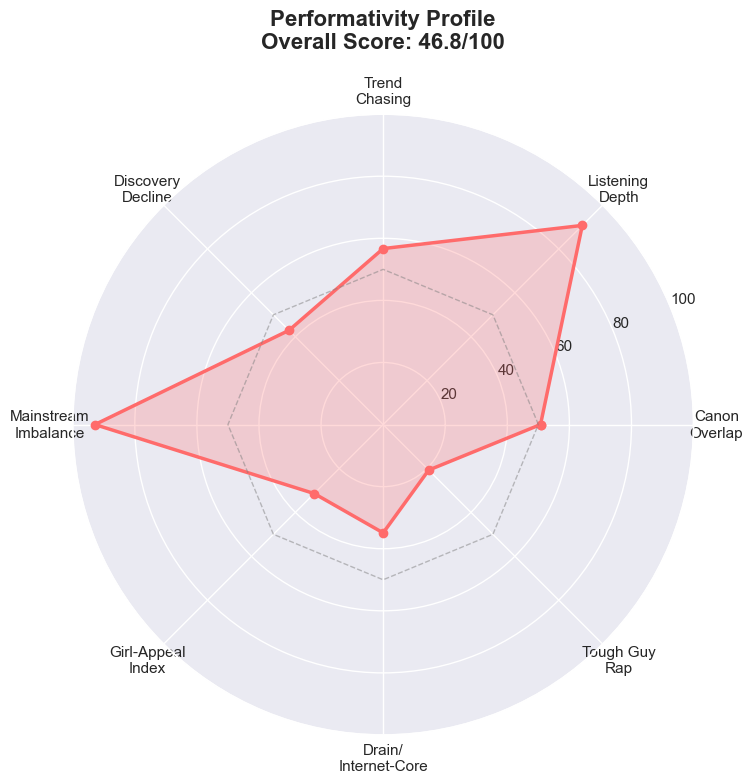

In [121]:
# Radar chart of the 5 dimensions
import matplotlib.patches as mpatches

categories = ['Canon\nOverlap', 'Listening\nDepth', 'Trend\nChasing', 
              'Discovery\nDecline', 'Mainstream\nImbalance', 'Girl-Appeal\nIndex',
              'Drain/\nInternet-Core', 'Tough Guy\nRap']
scores = [canon_score, depth_score, trend_score, discovery_score, balance_score, girl_appeal_score, drain_score, tough_rap_score]

# Number of variables
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Complete the loop
scores_plot = scores + scores[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Draw the shape
ax.plot(angles, scores_plot, 'o-', linewidth=2.5, color='#FF6B6B')
ax.fill(angles, scores_plot, alpha=0.25, color='#FF6B6B')

# Reference circle at 50
ref_scores = [50] * (N + 1)
ax.plot(angles, ref_scores, '--', linewidth=1, color='gray', alpha=0.5)

# Set labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 100)
ax.set_title(f'Performativity Profile\nOverall Score: {performativity_score:.1f}/100', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


## 7. Most & Least Performative Songs in Your Library

Finally, let's identify which specific songs in your library are the most and least "performative" — combining whether the artist is canon, how binge-y your listening was, and whether you only know the hits.

In [122]:
# Build a per-track performativity metric
track_stats = df.groupby(['artist', 'track']).agg(
    plays=('timestamp', 'size'),
    first_play=('timestamp', 'min'),
    last_play=('timestamp', 'max'),
    unique_days=('date', 'nunique')
).reset_index()

# Merge with artist-level info
track_stats = track_stats.merge(
    artist_depth[['artist', 'total_plays', 'unique_tracks', 'depth_ratio']], 
    on='artist', how='left'
)
track_stats = track_stats.merge(
    trend_df[['artist', 'peak_concentration']], 
    on='artist', how='left'
)

# Calculate track-level performativity factors
track_stats['is_canon'] = track_stats['artist'].isin(critical_canon).astype(int)
track_stats['is_mainstream'] = track_stats['artist'].isin(mainstream).astype(int)
track_stats['is_girl_appeal'] = track_stats['artist'].isin(girl_appeal).astype(int)
track_stats['is_drain'] = track_stats['artist'].isin(drain_internet).astype(int)
track_stats['is_tough_rap'] = track_stats['artist'].isin(tough_rap).astype(int)

# Longevity: how many days between first and last play
track_stats['lifespan_days'] = (track_stats['last_play'] - track_stats['first_play']).dt.days

# Concentration: plays per day listened (high = binge)
track_stats['plays_per_day'] = track_stats['plays'] / track_stats['unique_days'].clip(lower=1)

# Focus on tracks with 20+ plays for meaningful analysis
significant_tracks = track_stats[track_stats['plays'] >= 20].copy()

# Simple performativity score per track
# Higher = more performative
significant_tracks['track_perf_score'] = (
    significant_tracks['is_canon'] * 15 +                          # Canon artist
    significant_tracks['is_mainstream'] * 10 +                     # Mainstream
    significant_tracks['is_girl_appeal'] * 15 +                    # Girl-appeal artist
    significant_tracks['is_drain'] * 15 +                          # Drain/internet-core
    significant_tracks['is_tough_rap'] * 15 +                      # Tough guy rap
    (1 - significant_tracks['depth_ratio'].fillna(0.5)) * 15 +    # Low depth = performative
    significant_tracks['peak_concentration'].fillna(0.3) * 15      # Binge pattern
)

# Top most performative tracks
print('=== YOUR MOST "PERFORMATIVE" SONGS ===')
print('(Canon + girl-appeal + drain + tough-rap + surface listening + binge pattern)\n')
perf_tracks = significant_tracks.nlargest(20, 'track_perf_score')
for i, (_, row) in enumerate(perf_tracks.iterrows(), 1):
    print(f"  {i:2d}. {row['artist']} — {row['track']}")
    print(f"      {row['plays']} plays | Perf Score: {row['track_perf_score']:.1f}")

print('\n\n=== YOUR MOST "AUTHENTIC" SONGS ===')
print('(Non-canon + deep listening + sustained over time)\n')
auth_tracks = significant_tracks.nsmallest(20, 'track_perf_score')
for i, (_, row) in enumerate(auth_tracks.iterrows(), 1):
    print(f"  {i:2d}. {row['artist']} — {row['track']}")
    print(f"      {row['plays']} plays | Perf Score: {row['track_perf_score']:.1f}")


=== YOUR MOST "PERFORMATIVE" SONGS ===
(Canon + girl-appeal + drain + tough-rap + surface listening + binge pattern)

   1. Lorde — Homemade Dynamite
      30 plays | Perf Score: 56.7
   2. Lorde — Secrets from a Girl (Who's Seen It All)
      23 plays | Perf Score: 56.7
   3. Lorde — Supercut
      55 plays | Perf Score: 56.7
   4. Lorde — Writer in the Dark
      29 plays | Perf Score: 56.7
   5. Charli xcx — 1999
      20 plays | Perf Score: 56.7
   6. Charli xcx — 360
      35 plays | Perf Score: 56.7
   7. Charli xcx — 360 featuring robyn & yung lean
      50 plays | Perf Score: 56.7
   8. Charli xcx — 365
      75 plays | Perf Score: 56.7
   9. Charli xcx — Apple
      23 plays | Perf Score: 56.7
  10. Charli xcx — Femmebot (feat. Dorian Electra and Mykki Blanco)
      46 plays | Perf Score: 56.7
  11. Charli xcx — I think about it all the time
      28 plays | Perf Score: 56.7
  12. Charli xcx — Next Level Charli
      34 plays | Perf Score: 56.7
  13. Charli xcx — Porsche (feat

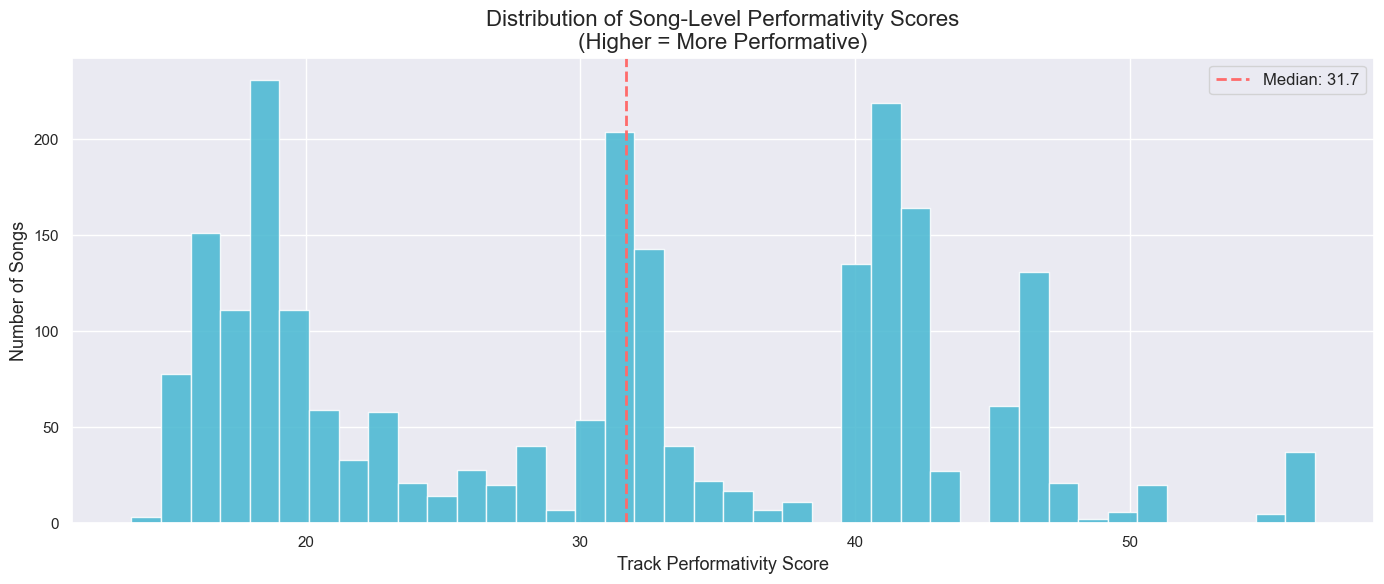

In [123]:
# Distribution of track performativity scores
fig, ax = plt.subplots(figsize=(14, 6))
ax.hist(significant_tracks['track_perf_score'], bins=40, color='#45B7D1', 
        edgecolor='white', alpha=0.85)
ax.axvline(x=significant_tracks['track_perf_score'].median(), color='#FF6B6B', 
           linestyle='--', linewidth=2, label=f'Median: {significant_tracks["track_perf_score"].median():.1f}')
ax.set_xlabel('Track Performativity Score')
ax.set_ylabel('Number of Songs')
ax.set_title('Distribution of Song-Level Performativity Scores\n(Higher = More Performative)')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 8. Key Findings & Conclusion

### Summary Statistics

In [124]:
print('=' * 65)
print('    FINAL REPORT: HOW PERFORMATIVE IS YOUR MUSIC TASTE?')
print('=' * 65)
print(f'\n  📊 Dataset: {len(df):,} scrobbles across {df.artist.nunique():,} artists')
print(f'  📅 Period: {df.timestamp.min().strftime("%b %Y")} to {df.timestamp.max().strftime("%b %Y")}')
print(f'\n  🎭 Overall Performativity Score: {performativity_score:.1f} / 100')
print(f'\n  {verdict}')
print(f'\n  Key Insights:')
print(f'  • {canon_pct:.1f}% of your listening is critically acclaimed "canon" artists')
print(f'  • {artists_for_50} artists make up 50% of your entire listening history')
print(f'  • Your most-played artist (JPEGMAFIA at {artist_counts.max():,} plays) is')
print(f'    actually underground — a strong authenticity signal')
print(f'  • Discovery rate trend: {"declining" if second_half < first_half else "stable/growing"}')
print(f'  • You\'ve listened to {(track_stats.plays >= 100).sum()} songs 100+ times')
print('\n' + '=' * 65)

    FINAL REPORT: HOW PERFORMATIVE IS YOUR MUSIC TASTE?

  📊 Dataset: 151,811 scrobbles across 3,023 artists
  📅 Period: Aug 2021 to Mar 2026

  🎭 Overall Performativity Score: 46.8 / 100

  🎵 MOSTLY AUTHENTIC — You engage deeply and explore beyond the canon.

  Key Insights:
  • 35.5% of your listening is critically acclaimed "canon" artists
  • 39 artists make up 50% of your entire listening history
  • Your most-played artist (JPEGMAFIA at 7,596 plays) is
    actually underground — a strong authenticity signal
  • Discovery rate trend: declining
  • You've listened to 134 songs 100+ times



### Methodology Notes

**Limitations of this analysis:**
- The "critical canon" and "mainstream/underground" lists are manually curated and inherently subjective. In a more robust version, we'd pull listener counts from Spotify or Last.fm's API to objectively measure popularity.
- Scrobble data doesn't capture *passive* vs. *active* listening — having a playlist on shuffle is different from intentionally choosing an album.
- The concept of "performativity" itself is subjective — enjoying critically acclaimed music doesn't make someone fake. This analysis is exploratory and meant to be fun, not definitive.

**Potential extensions:**
- Pull real-time listener counts from Spotify/Last.fm API for objective popularity tiers
- Sentiment analysis on artist tags to identify "aesthetic" vs. "substance" listening
- Compare personal listening patterns against aggregate Last.fm user data
- Build an interactive Tableau dashboard from these findings

---

**Tools used:** Python (Pandas, NumPy, Matplotlib, Seaborn)  
**Data:** Personal Last.fm scrobble export  
**GitHub:** [https://github.com/Mahirrrr]